In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from sklearn.metrics import f1_score, confusion_matrix
import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from collections import Counter
import os
import glob
import pyedflib
import yaml
import json
import h5py
import numpy as np
import pandas as pd
import datetime
from tqdm import tqdm
import multiprocessing
from loguru import logger
import warnings
from scipy.signal import butter, filtfilt, resample
import mne
sys.path.append("..")
sys.path.append("../sleepfm")
"""from preprocessing.preprocessing import EDFToHDF5Converter"""
from models.dataset import SetTransformerDataset, collate_fn
from models.models import SetTransformer, SleepEventLSTMClassifier, DiagnosisFinetuneFullLSTMCOXPHWithDemo
from utils import load_config, load_data, save_data, count_parameters
from torch.utils.data import Dataset, DataLoader
import torch
from torch import nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
device = torch.device("cuda")
print(device)

cuda


In [14]:
class EDFToHDF5Converter:
    def __init__(self, root_dir, target_dir, resample_rate=512, num_threads=1, num_files=-1, channels=None):
        self.resample_rate = resample_rate 
        self.root_dir = root_dir
        self.target_dir = target_dir
        self.num_threads = num_threads
        self.num_files = num_files
        self.channels = channels
        self.file_locations = self.get_files() 
        # self.scorers = ['ES','LS','MS']
        self.flow_events = {'Central Apnea': 1, 'Mixed Apnea': 2, 'Obstructive Apnea': 3, 'Hypopnea': 4, 'RERA': 5}
        self.plm_events = {'P-Marker': 1, 'I-Marker': 2, 'LM Body position': 3, 'LM Resp': 4}
        self.arousal_events = {'Autonomic arousals': 1, 'Respiratory Arousal': 2}
        self.sleep_stages = {'Wake': 0, 'Rem': 1, 'N1': 2, 'N2': 3, 'N3': 4, 'Artifact': 5}


    def get_files(self):
        # Search for all '.edf' files within each subdirectory of the root directory
        file_paths = glob(os.path.join(self.root_dir, '**/*.[eE][dD][fF]'), recursive=True)
        file_names = [os.path.basename(path) for path in file_paths]
        return file_paths, file_names
    
    def extract_start_time(self, file_path):
        with open(file_path, 'r') as file:
            lines = [next(file) for _ in range(5)]
            
        for line in lines:
            if line.startswith("Start Time:"):
                return line.split(": ", 1)[1].strip()
        return "Start Time not found"

    def create_signal_from_events(self, df, total_seconds, event_type = None):
        valid_types = {'flow', 'plm', 'arousal','stages'}
        if event_type not in valid_types:
            raise ValueError("event_type must be 'flow', 'plm', or 'arousal'")
        
        total_samples = int(total_seconds * self.resample_rate)
        # make initial array of zeros with length total_sec
        event_array = np.zeros(total_samples)

        # go through each event and mark the corresponding seconds in the array
        for _, row in df.iterrows():
            event_start = int(row['sec_from_start'] * self.resample_rate)
            event_stop = int(row['sec_from_start'] * self.resample_rate + row['dur'] * self.resample_rate)
            if event_type == 'flow':
                event_code = self.flow_events.get(row['event_type'], 0)
            elif event_type == 'plm':
                event_code = self.plm_events.get(row['event_type'], 0)
            elif event_type == 'arousal':
                event_code = self.arousal_events.get(row['event_type'], 0)
            elif event_type == 'stages':
                event_code = self.sleep_stages.get(row['event_type'])
            
            event_array[event_start:event_stop] = event_code
        
        return event_array

    def make_event_dataframe(self, folder, event_type = None):
        valid_types = {'flow', 'plm', 'arousal','stages'}
        if event_type not in valid_types:
            raise ValueError("event_type must be 'flow', 'plm', or 'arousal'")
        if event_type == 'flow':
            flow_file = os.path.join(self.root_dir,folder,'Flow Events.txt')
            df = pd.read_csv(flow_file, delimiter=';',skiprows=5, names=['start-stop', 'duration', 'event_type'])
        elif event_type == 'plm':
            flow_file = os.path.join(self.root_dir,folder,'PLM Events.txt')
            df = pd.read_csv(flow_file, delimiter=';',skiprows=5, names=['start-stop', 'duration', 'event_type'])
        elif event_type == 'arousal':
            flow_file = os.path.join(self.root_dir,folder,'Autonomic arousals.txt')
            dfAutonomic = pd.read_csv(flow_file, delimiter=';',skiprows=5, names=['start-stop', 'duration', 'event_type'])
            flow_file = os.path.join(self.root_dir,folder,'Classification arousals.txt')
            dfClassification = pd.read_csv(flow_file, delimiter=';',skiprows=5, names=['start-stop', 'duration', 'event_type'])
            df = pd.concat([dfAutonomic,dfClassification], ignore_index=True)
        elif event_type == 'stages':
            flow_file1 = os.path.join(self.root_dir,folder,'Flow Events.txt')
            start_time = self.extract_start_time(file_path = flow_file1)
            start_time = datetime.datetime.strptime(start_time, "%m/%d/%Y %I:%M:%S %p")
            flow_file = os.path.join(self.root_dir,folder,'Sleep profile.txt')
            df = pd.read_csv(flow_file, delimiter=';',skiprows=7, names=['start', 'event_type']) 
            df['start'] = pd.to_datetime(df['start'], format='%H:%M:%S,%f').dt.time
            df['sec_from_start'] = df['start'].apply(lambda x: (datetime.datetime.combine(datetime.date(1,1,1),x) - datetime.datetime.combine(datetime.date(1,1,1),start_time.time())).total_seconds())
            df['dur'] = 30
            df['event_type'] = df['event_type'].str.strip()
            if df['sec_from_start'].iloc[0] < 0:
                df['dur'][0] = 30 + df['sec_from_start'].iloc[0]
                df['sec_from_start'].iloc[0] = 0
            df.loc[df.sec_from_start < 0, 'sec_from_start'] += 24*60*60
            return df

        # df = pd.read_csv(flow_file, delimiter=';',skiprows=5, names=['start-stop', 'duration', 'event_type'])
        if len(df.values) != 0:
            df[['start', 'stop']] = df['start-stop'].str.split('-', expand=True)

            start_time = self.extract_start_time(file_path = flow_file)
            start_time = datetime.datetime.strptime(start_time, "%m/%d/%Y %I:%M:%S %p")

            df['start'] = pd.to_datetime(df['start'], format='%H:%M:%S,%f').dt.time
            df['stop'] = pd.to_datetime(df['stop'], format='%H:%M:%S,%f').dt.time
            df['sec_from_start'] = df['start'].apply(lambda x: (datetime.datetime.combine(datetime.date(1,1,1),x) - datetime.datetime.combine(datetime.date(1,1,1),start_time.time())).total_seconds())
            df['sec_from_stop'] = df['stop'].apply(lambda x: (datetime.datetime.combine(datetime.date(1,1,1),x) - datetime.datetime.combine(datetime.date(1,1,1),start_time.time())).total_seconds())

            df['duration'] = pd.to_numeric(df['duration'])

            df = df[['start', 'stop', 'duration', 'event_type', 'sec_from_start','sec_from_stop']]

            df.loc[df.sec_from_start < 0, 'sec_from_start'] += 24*60*60
            df.loc[df.sec_from_stop < 0, 'sec_from_stop'] += 24*60*60
            df['dur'] = df['sec_from_stop'] - df['sec_from_start']
        else:
            df  = pd.DataFrame(columns = ['start', 'stop', 'duration', 'event_type', 'sec_from_start','sec_from_stop', 'dur'])

        return df

    def convert_events(self, folder,total_seconds,event_type):
        df_events = self.make_event_dataframe(folder, event_type=event_type)
        event_array = self.create_signal_from_events(df=df_events, total_seconds=total_seconds, event_type=event_type)
        return event_array

    def read_edf_old(self, file_path):
        logger.info('reading edf')
        with pyedflib.EdfReader(file_path) as edf:
            signals = [edf.readSignal(i) for i in range(edf.signals_in_file)]
            sample_rates = np.array([edf.getSampleFrequency(i) for i in range(edf.signals_in_file)])
            channel_names = np.array([edf.getLabel(i) for i in range(edf.signals_in_file)])
            # annotations = []#edf.readAnnotations()
        return signals, sample_rates, channel_names
    
    def read_edf(self, file_path):
        logger.info(f'Reading EDF: {os.path.basename(file_path)}')
        
        try:
            # Charger avec filtrage de canaux si spécifié
            if self.channels is not None and len(self.channels) > 0:
                # Vérifier d'abord quels canaux existent
                logger.info(f'Checking available channels...')
                raw_temp = mne.io.read_raw_edf(file_path,include=self.channels, preload=False, verbose=False)
                
                available_channels = [ch for ch in self.channels if ch in raw_temp.ch_names]
                missing_channels = set(self.channels) - set(available_channels)
                
                if missing_channels:
                    logger.warning(f"⚠️  Canaux manquants: {missing_channels}")
                
                if not available_channels:
                    raise ValueError(f"❌ Aucun des canaux spécifiés n'a été trouvé dans {file_path}\n"
                                f"   Canaux demandés: {self.channels}\n"
                                f"   Canaux disponibles: {raw_temp.ch_names}")
                
                logger.info(f'✅ Chargement de {len(available_channels)}/{len(self.channels)} canaux')
                raw = mne.io.read_raw_edf(file_path, include=available_channels, preload=True, verbose=False)
            else:
                # Charger tous les canaux si aucun filtre spécifié
                logger.info('Loading all channels (no filter specified)')
                raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
            
            # Extraire les données
            signals = [raw.get_data(picks=[ch_name])[0] for ch_name in raw.ch_names]
            sample_rates = np.array([raw.info['sfreq'] for _ in raw.ch_names])
            channel_names = np.array(raw.ch_names)
            
            logger.info(f'✅ Loaded {len(channel_names)} channels, {len(signals[0])} samples at {sample_rates[0]} Hz')
            
            return signals, sample_rates, channel_names
            
        except Exception as e:
            logger.error(f"❌ Error reading {file_path}: {str(e)}")
            raise

    def resample_signals_old(self, signals, sample_rates):
        # Vectorization and broadcasting could be applied within the resample function itself
        logger.info('resampling signals')
        resampled_signals = [resample(signal, int(len(signal) * self.resample_rate / rate))
                             for signal, rate in zip(signals, sample_rates)]
        standardized_signals = [(signal - np.mean(signal)) / np.std(signal) for signal in resampled_signals]
        # add signal names as input and filter the spo2 preprocessing as scaled 0 to 1
        return np.stack(standardized_signals)# Using np.stack for proper array dimensions


    def safe_standardize(self, signal):
        mean = np.mean(signal)
        std = np.std(signal)
        
        if std == 0:
            standardized_signal = (signal - mean)
        else:
            standardized_signal = (signal - mean) / std
        
        return standardized_signal
        
    def filter_signal(self, signal, sample_rate):
        print("Filtering signal")
        nyquist_freq = sample_rate / 2
        cutoff = min(self.resample_rate / 2, nyquist_freq)
        normalized_cutoff = cutoff / nyquist_freq
        b, a = butter(4, normalized_cutoff, btype='low', analog=False)
        filtered_signal = filtfilt(b, a, signal)
        return filtered_signal

    def resample_signals(self, signals, sample_rates):
        logger.info('resampling signals')
        resampled_signals = []
        for signal, rate in zip(signals, sample_rates):
            # Calculate the duration of the signal
            duration = len(signal) / rate
            
            # Original time points
            original_time_points = np.linspace(0, duration, num=len(signal), endpoint=False)
            
            # New sample rate and new time points
            new_sample_count = int(duration * self.resample_rate)
            new_time_points = np.linspace(0, duration, num=new_sample_count, endpoint=False)

            #filter signal
            if rate > self.resample_rate:
                signal = self.filter_signal(signal, rate)
            
            # Linear interpolation
            resampled_signal = np.interp(new_time_points, original_time_points, signal)
            
            # Standardize the resampled signal (optional, based on your need)
            # standardized_signal = (resampled_signal - np.mean(resampled_signal)) / np.std(resampled_signal)
            standardized_signal = self.safe_standardize(resampled_signal)
            
            if np.isnan(standardized_signal).any():
                logger.info('Found NaN in the resampled signal.')
                # Handle the NaN case here (e.g., skip or fix the signal)
                continue

            resampled_signals.append(standardized_signal)

        
        return np.stack(resampled_signals)  # Stack for a consistent output format

    def save_to_hdf5(self, signals, channel_names, annotation_signals, annotation_names, file_path):
        logger.info('saving hdf5')
        samples_per_chunk = 5 * 60 * self.resample_rate
        with h5py.File(file_path, 'w') as hdf:
            for signal, name in zip(signals, channel_names):
                dataset_name = self._get_unique_name(hdf, name)
                hdf.create_dataset(dataset_name, data=signal,
                                   dtype='float16', chunks=(samples_per_chunk,), compression="gzip")

            for annot_signal, annot_name in zip(annotation_signals, annotation_names):
                hdf.create_dataset(annot_name, data=annot_signal)

    def _get_unique_name(self, hdf, base_name):
        # Helper method to ensure dataset names are unique
        i = 1
        unique_name = base_name
        while unique_name in hdf:
            unique_name = f"{base_name}_{i}"
            i += 1
        return unique_name

    def get_annotations(self, total_seconds, folder):
        # folder_path = 'C:/Users/45223/OneDrive - Danmarks Tekniske Universitet/PhD/Oliver_triple_scored/triple_scored_studies1/CSA009/ES'
        flow_events = self.convert_events(folder = folder, total_seconds = total_seconds, event_type = 'flow')
        plm_events = self.convert_events( folder = folder, total_seconds = total_seconds, event_type = 'plm')
        arousal_events = self.convert_events( folder = folder, total_seconds = total_seconds, event_type = 'arousal')
        sleep_stages = self.convert_events( folder = folder, total_seconds = total_seconds, event_type = 'stages')

        return flow_events, plm_events, arousal_events, sleep_stages
    
    def convert(self, edf_path, hdf5_path):
        signals, sample_rates, channel_names = self.read_edf(edf_path)
        resampled_signals = self.resample_signals(signals, sample_rates)
        total_duration_seconds = len(signals[0])/sample_rates[0]
        event_signals = []
        event_signal_names = []
        self.save_to_hdf5(resampled_signals, channel_names,event_signals,event_signal_names, hdf5_path)

    def convert_multiprocessing(self, args):
        edf_files = args

        for edf_file in tqdm(edf_files, desc="Converting EDF files"):

            if edf_file.endswith(".edf"):
                replace_str = ".edf"
            elif edf_file.endswith(".EDF"):
                replace_str = ".EDF"
            hdf5_file = os.path.join(self.target_dir, edf_file.split('/')[-1].replace(replace_str, '.hdf5'))

            if os.path.exists(hdf5_file):
                logger.info(f"File already processed: {hdf5_file}")
                continue
            try:
                self.convert(edf_file, hdf5_file)
            except Exception as e:
                warnings.warn(f"Warning: Could not process the file {edf_file}. Error: {str(e)}")
                continue
        return [1]

    def convert_all(self):
        edf_files, edf_names = self.get_files() 
        # folders = self.get_folders()
        for edf_file in tqdm(edf_files, desc="Converting EDF files"):
            # edf_files = [os.path.join(folder, f) for f in os.listdir(os.path.join(self.root_dir,folder)) if f.endswith('.edf')]
            # edf_file = os.path.join(self.root_dir,edf_files[0])
            if edf_file.endswith(".edf"):
                replace_str = ".edf"
            elif edf_file.endswith(".EDF"):
                replace_str = ".EDF"
            hdf5_file = os.path.join(self.target_dir,edf_file.split('/')[-1].replace(replace_str, '.hdf5'))
            # logger.info(edf_file)
            # logger.info(hdf5_file)

            try:
                self.convert(edf_file, hdf5_file)
            except Exception as e:
                warnings.warn(f"Warning: Could not process the file {edf_file}. Error: {str(e)}")
                continue

    def convert_all_multiprocessing(self):
        edf_files, edf_names = self.get_files() 

        if self.num_files != -1:
            edf_files = edf_files[:self.num_files]

        edf_files_chunks = np.array_split(edf_files, self.num_threads)
        tasks = [(edf_files_chunk) for edf_files_chunk in edf_files_chunks]
        with multiprocessing.Pool(self.num_threads) as pool:
            preprocessed_results = [y for x in pool.imap_unordered(self.convert_multiprocessing, tasks) for y in x]

    def convert_with_annot(self, edf_path, hdf5_path, folder):
        signals, sample_rates, channel_names = self.read_edf(edf_path)
        resampled_signals = self.resample_signals(signals, sample_rates)
        total_duration_seconds = len(signals[0])/sample_rates[0]
        event_signals = []
        event_signal_names = []
        for scorer in self.scorers:
            scorer_folder = os.path.join(folder, scorer) 
            flow_events, plm_events, arousal_events, sleep_stages = self.get_annotations(total_seconds = total_duration_seconds, folder = scorer_folder)
            event_signals.extend([flow_events, plm_events, arousal_events, sleep_stages])
            event_signal_names.extend(['flow_events'+scorer, 'plm_events'+scorer, 'arousal_events'+scorer, 'sleep_stages'+scorer])
        self.save_to_hdf5(resampled_signals, channel_names,event_signals,event_signal_names, hdf5_path)

    def convert_all_with_annot(self):
        edf_files, edf_names = self.get_files() 
        folders = self.get_folders()
        for folder in tqdm(folders, desc="Converting EDF files"):
            edf_files = [os.path.join(folder, f) for f in os.listdir(os.path.join(self.root_dir,folder)) if f.lower().endswith('.edf')]
            edf_file = os.path.join(self.root_dir,edf_files[0])
            # header = self.extract_end_time(edf_file)
            # hdf5_file = os.path.join(self.root_dir, edf_file.replace('.edf', '.hdf5'))
            if edf_file.endswith(".edf"):
                replace_str = ".edf"
            elif edf_file.endswith(".EDF"):
                replace_str = ".EDF"
            hdf5_file = os.path.join(self.target_dir,edf_file.split('\\')[-1].replace(replace_str, '.hdf5'))

            # logger.info(hdf5_file)
            self.convert_with_annot(edf_file, hdf5_file, folder)
    def plot_results(self, resampled_signals, channel_names):
        print("plotting resampled_signals")
        num_signals = len(resampled_signals)
        fig, axs = plt.subplots(num_signals, 1, figsize=(15, 3*num_signals), sharex=True)
        samples_to_plot = 10 * self.resample_rate
        sample_to_start = 10 * self.resample_rate
        for i, (signal, name) in enumerate(zip(resampled_signals, channel_names)):
            signal_chunk = signal[sample_to_start:sample_to_start+samples_to_plot]
            axs[i].plot(signal_chunk)
            axs[i].set_title(name)
            axs[i].set_ylabel('Amplitude')
        
        axs[-1].set_xlabel('Samples')
        plt.tight_layout()
        plt.show()

    def plot_first_results(self, resampled_signals, channel_names):
        print("plotting resampled_signals")
        num_signals = len(resampled_signals)
        fig = plt.figure(figsize=(15, 3))
        samples_to_plot = 10 * self.resample_rate
        sample_to_start = 10 * self.resample_rate
        for i, (signal, name) in enumerate(zip(resampled_signals, channel_names)):
            signal_chunk = signal[sample_to_start:sample_to_start+samples_to_plot]
            plt.plot(signal_chunk)
            plt.title(name)
            plt.ylabel('Amplitude')
            break
        
        plt.xlabel('Samples')
        plt.tight_layout()
        plt.show()

    def process_and_plot_single_file(self, edf_path):
        signals, sample_rates, channel_names = self.read_edf(edf_path)
        resampled_signals = self.resample_signals(signals, sample_rates)
        #self.plot_results(resampled_signals, channel_names)
        self.plot_first_results(resampled_signals, channel_names)
    

In [15]:
CHANNEL_GROUPS = {
    "EEG": ["F3", "F4", "C3", "C4", "Cz", "O1", "O2"],       
    "EOG": ["EOG G", "EOG D"],
    "EMG": ["EMG JG", "EMG JD", "EMG 1", "EMG 2"],          
    "EKG": ["ECG 1", "ECG 2"],
    "RESP": ["Flow", "Canula", "Thermistance", "Thoracic", "Abdominal", "Pleth", "SpO2"]                   
}

CHANNEL_OI = sorted({ch for grp in CHANNEL_GROUPS.values() for ch in grp})

CATEGORY_MAPPING = {
    "EEG": "BAS",
    "EOG": "BAS",
    "EKG": "EKG",
    "EMG": "EMG",
    "RESP": "RESP"
}

CHANNEL_GROUPS_FOR_MODEL = {'BAS': [], 'EKG': [], 'RESP': [], 'EMG': []}

for category, channels in CHANNEL_GROUPS.items():
    model_category = CATEGORY_MAPPING.get(category, 'BAS')
    CHANNEL_GROUPS_FOR_MODEL[model_category].extend(channels)

print(CHANNEL_GROUPS_FOR_MODEL)


{'BAS': ['F3', 'F4', 'C3', 'C4', 'Cz', 'O1', 'O2', 'EOG G', 'EOG D'], 'EKG': ['ECG 1', 'ECG 2'], 'RESP': ['Flow', 'Canula', 'Thermistance', 'Thoracic', 'Abdominal', 'Pleth', 'SpO2'], 'EMG': ['EMG JG', 'EMG JD', 'EMG 1', 'EMG 2']}


In [16]:
'EOG G', 'EOG D', 'ECG 1', 'Flow ?? ', 'Canula', 'Thermistance', 'Pleth e, emg ?? ', 'EMG JG', 'EMG JD', 'EMG 1', 'EMG 2'

('EOG G',
 'EOG D',
 'ECG 1',
 'Flow ?? ',
 'Canula',
 'Thermistance',
 'Pleth e, emg ?? ',
 'EMG JG',
 'EMG JD',
 'EMG 1',
 'EMG 2')

In [17]:
import os
from glob import glob
from tqdm import tqdm
import time

edf_folder = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\data"
output_folder = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_downsampling"

os.makedirs(output_folder, exist_ok=True)

def edf_to_hdf5(input_folder, output_folder):
    # Trouver tous les EDF
    edf_files = glob(os.path.join(input_folder, "**/*.edf"), recursive=True)
    edf_files += glob(os.path.join(input_folder, "**/*.EDF"), recursive=True)
    
    print(f"\n📁 {len(edf_files)} fichiers EDF trouvés\n")
    
    converter = EDFToHDF5Converter(
        root_dir=input_folder,
        target_dir=output_folder,
        resample_rate=128,
        channels=CHANNEL_OI
    )
    
    # Convertir avec barre de progression
    success = 0
    errors = 0
    skipped = 0
    
    for edf_path in tqdm(edf_files, desc="🔄 Conversion", unit="fichier"):
        basename = os.path.basename(edf_path).replace('.edf', '').replace('.EDF', '')
        hdf5_path = os.path.join(output_folder, f"{basename}.hdf5")
        
        # Skip si existe déjà
        if os.path.exists(hdf5_path):
            skipped += 1
            tqdm.write(f"⏭️  {basename} (déjà converti)")
            continue
        
        try:
            start = time.time()
            converter.convert(edf_path, hdf5_path)
            duration = time.time() - start
            success += 1
            tqdm.write(f"✅ {basename} ({duration:.1f}s)")
        except Exception as e:
            errors += 1
            tqdm.write(f"❌ {basename}: {str(e)[:50]}")
    
    # Résumé
    print(f"\n{'='*50}")
    print(f"✅ Réussis:  {success}")
    print(f"⏭️  Ignorés:  {skipped}")
    print(f"❌ Erreurs:  {errors}")
    print(f"{'='*50}")


def txt_to_csv(input_folder, output_folder):
    
    os.makedirs(output_folder, exist_ok=True)
    
    STAGE_TO_NUMBER = {
        'W': 0,
        '1': 1,
        '2': 2,
        '3': 3,
        '4': 3,
        'R': 4
    }
    
    STAGE_NAMES = {
        0: "Wake",
        1: "Stage 1",
        2: "Stage 2",
        3: "Stage 3",
        4: "REM"
    }
    
    txt_files = glob(os.path.join(input_folder, "*.txt"))
    txt_files += glob(os.path.join(input_folder, "*.TXT"))
    
    print(f"\n📁 {len(txt_files)} fichiers TXT trouvés\n")
    
    if len(txt_files) == 0:
        return
    
    success = 0
    errors = 0
    
    for txt_file in tqdm(txt_files, desc="🔄 Conversion TXT→CSV", unit="fichier"):
        try:
            # Nom du fichier original
            original_basename = os.path.basename(txt_file).replace('.txt', '').replace('.TXT', '')
            
            # Enlever le préfixe "PSG4_Hypnogram_Export_"
            if original_basename.startswith("PSG4_Hypnogram_Export_"):
                new_basename = original_basename.replace("PSG4_Hypnogram_Export_", "")
            else:
                new_basename = original_basename
            
            # Chemin du CSV de sortie
            csv_file = os.path.join(output_folder, f"{new_basename}.csv")
            
            # Charger les stages (30s par ligne)
            stages_30s = np.loadtxt(txt_file, dtype=str)
            n_epochs_30s = len(stages_30s)
            starts = np.arange(0, n_epochs_30s * 30, 30)
            stops = starts + 30
            
            # Créer le DataFrame
            df = pd.DataFrame({
                'Start': starts,
                'Stop': stops,
                'StageName': [STAGE_NAMES.get(STAGE_TO_NUMBER.get(s, -1), "Unknown") for s in stages_30s],
                'StageNumber': [STAGE_TO_NUMBER.get(s, -1) for s in stages_30s],
                'EmbeddingNumber': np.arange(n_epochs_30s)
            })
            
            # Sauvegarder
            df.to_csv(csv_file, index=False)
            
            success += 1
            tqdm.write(f"✅ {original_basename} → {new_basename}.csv")
        except Exception as e:
            errors += 1
            tqdm.write(f"❌ {os.path.basename(txt_file)}: {str(e)[:50]}")

    print(f"✅ Convertis: {success}")
    print(f"❌ Erreurs:   {errors}")
    print(f"📂 Dossier de sortie: {output_folder}")

# ========== UTILISATION ==========
input_folder = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\data"

txt_to_csv(input_folder, output_folder)
edf_to_hdf5(edf_folder, output_folder)



📁 30 fichiers TXT trouvés



🔄 Conversion TXT→CSV:  27%|██▋       | 8/30 [00:00<00:00, 74.44fichier/s]

✅ PSG4_Hypnogram_Export_C1_001_PSG1 → C1_001_PSG1.csv
✅ PSG4_Hypnogram_Export_C1_002_PSG1 → C1_002_PSG1.csv
✅ PSG4_Hypnogram_Export_C1_003_PSG1 → C1_003_PSG1.csv
✅ PSG4_Hypnogram_Export_C1_004_PSG1 → C1_004_PSG1.csv
✅ PSG4_Hypnogram_Export_C1_005_PSG1 → C1_005_PSG1.csv
✅ PSG4_Hypnogram_Export_HI_001_PSG1 → HI_001_PSG1.csv
✅ PSG4_Hypnogram_Export_HI_002_PSG1 → HI_002_PSG1.csv
✅ PSG4_Hypnogram_Export_HI_003_PSG1 → HI_003_PSG1.csv
✅ PSG4_Hypnogram_Export_HI_004_PSG1 → HI_004_PSG1.csv
✅ PSG4_Hypnogram_Export_HI_005_PSG1 → HI_005_PSG1.csv
✅ PSG4_Hypnogram_Export_N1_001_PSG1 → N1_001_PSG1.csv
✅ PSG4_Hypnogram_Export_N1_002_PSG1 → N1_002_PSG1.csv
✅ PSG4_Hypnogram_Export_N1_003_PSG1 → N1_003_PSG1.csv


🔄 Conversion TXT→CSV:  27%|██▋       | 8/30 [00:00<00:00, 74.44fichier/s]

✅ PSG4_Hypnogram_Export_N1_004_PSG1 → N1_004_PSG1.csv
✅ PSG4_Hypnogram_Export_N1_005_PSG1 → N1_005_PSG1.csv


...

✅ PSG4_Hypnogram_Export_C1_001_PSG1 → C1_001_PSG1.csv
✅ PSG4_Hypnogram_Export_C1_002_PSG1 → C1_002_PSG1.csv
✅ PSG4_Hypnogram_Export_C1_003_PSG1 → C1_003_PSG1.csv
✅ PSG4_Hypnogram_Export_C1_004_PSG1 → C1_004_PSG1.csv
✅ PSG4_Hypnogram_Export_C1_005_PSG1 → C1_005_PSG1.csv
✅ PSG4_Hypnogram_Export_HI_001_PSG1 → HI_001_PSG1.csv
✅ PSG4_Hypnogram_Export_HI_002_PSG1 → HI_002_PSG1.csv
✅ PSG4_Hypnogram_Export_HI_003_PSG1 → HI_003_PSG1.csv
✅ PSG4_Hypnogram_Export_HI_004_PSG1 → HI_004_PSG1.csv
✅ PSG4_Hypnogram_Export_HI_005_PSG1 → HI_005_PSG1.csv
✅ PSG4_Hypnogram_Export_N1_001_PSG1 → N1_001_PSG1.csv
✅ PSG4_Hypnogram_Export_N1_002_PSG1 → N1_002_PSG1.csv
✅ PSG4_Hypnogram_Export_N1_003_PSG1 → N1_003_PSG1.csv
✅ PSG4_Hypnogram_Export_N1_004_PSG1 → N1_004_PSG1.csv


🔄 Conversion TXT→CSV: 100%|██████████| 30/30 [00:00<00:00, 78.27fichier/s]


✅ PSG4_Hypnogram_Export_N1_005_PSG1 → N1_005_PSG1.csv
✅ Convertis: 30
❌ Erreurs:   0
📂 Dossier de sortie: C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\train_downsampling

📁 30 fichiers EDF trouvés



🔄 Conversion: 100%|██████████| 30/30 [00:00<00:00, 198.70fichier/s]

⏭️  C1_001_PSG1 (déjà converti)
⏭️  C1_002_PSG1 (déjà converti)
⏭️  C1_003_PSG1 (déjà converti)
⏭️  C1_004_PSG1 (déjà converti)
⏭️  C1_005_PSG1 (déjà converti)
⏭️  HI_001_PSG1 (déjà converti)
⏭️  HI_002_PSG1 (déjà converti)
⏭️  HI_003_PSG1 (déjà converti)
⏭️  HI_004_PSG1 (déjà converti)
⏭️  HI_005_PSG1 (déjà converti)
⏭️  N1_001_PSG1 (déjà converti)
⏭️  N1_002_PSG1 (déjà converti)
⏭️  N1_003_PSG1 (déjà converti)
⏭️  N1_004_PSG1 (déjà converti)
⏭️  N1_005_PSG1 (déjà converti)
⏭️  C1_001_PSG1 (déjà converti)
⏭️  C1_002_PSG1 (déjà converti)
⏭️  C1_003_PSG1 (déjà converti)
⏭️  C1_004_PSG1 (déjà converti)
⏭️  C1_005_PSG1 (déjà converti)
⏭️  HI_001_PSG1 (déjà converti)
⏭️  HI_002_PSG1 (déjà converti)
⏭️  HI_003_PSG1 (déjà converti)
⏭️  HI_004_PSG1 (déjà converti)
⏭️  HI_005_PSG1 (déjà converti)
⏭️  N1_001_PSG1 (déjà converti)
⏭️  N1_002_PSG1 (déjà converti)
⏭️  N1_003_PSG1 (déjà converti)
⏭️  N1_004_PSG1 (déjà converti)
⏭️  N1_005_PSG1 (déjà converti)

✅ Réussis:  0
⏭️  Ignorés:  30
❌ Erreur

In [18]:
from glob import glob
model_path = "../sleepfm/checkpoints/model_base"
channel_groups_path = "../sleepfm/configs/channel_groups.json"
config_path = os.path.join(model_path, "config.json")

config = load_config(config_path)

def create_embedding_and_filtering(config,hdf5_paths,collate_fn,output_dir, output_5min_agg_dir, checkpoint=True, converting_edf=True):
    
    edf = glob(os.path.join(hdf5_paths, "*.edf"))
    txt = glob(os.path.join(hdf5_paths, "*.txt"))
    if converting_edf and len(edf) > 0:
        edf_to_hdf5(input_folder=hdf5_paths, output_folder=hdf5_paths)
    if len(txt) > 0:
        txt_to_csv(input_folder=hdf5_paths, output_folder=hdf5_paths)
        
    modality_types = config["modality_types"]
    in_channels = config["in_channels"]
    patch_size = config["patch_size"]
    embed_dim = config["embed_dim"]
    num_heads = config["num_heads"]
    num_layers = config["num_layers"]
    pooling_head = config["pooling_head"]
    dropout = 0.0

    print(f"CUDA disponible: {torch.cuda.is_available()}")
    print(f"Version PyTorch: {torch.__version__}")

    model_class = getattr(sys.modules[__name__], config['model'])
    model = model_class(in_channels, patch_size, embed_dim, num_heads, num_layers, pooling_head=pooling_head, dropout=dropout)

    device = torch.device("cuda")
    print(device)

    if device.type == "cuda":
        model = torch.nn.DataParallel(model)

    model.to(device)
    if checkpoint:
        checkpoint = torch.load(os.path.join(model_path, "best.pt"))
        model.load_state_dict(checkpoint["state_dict"])
    model.eval()

    hdf5_files = glob(os.path.join(hdf5_paths, "*.hdf5"))
    dataset = SetTransformerDataset(config, CHANNEL_GROUPS_FOR_MODEL , hdf5_paths=hdf5_files, split="test")
    dataloader = torch.utils.data.DataLoader(dataset, 
                                                batch_size=16, 
                                                num_workers=1, 
                                                shuffle=False, 
                                                collate_fn=collate_fn)

    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(output_5min_agg_dir, exist_ok=True)
    
    with torch.no_grad():
        with tqdm(total=len(dataloader)) as pbar:
            for batch in dataloader:
                batch_data, mask_list, file_paths, dset_names_list, chunk_starts = batch
                (bas, resp, ekg, emg) = batch_data
                (mask_bas, mask_resp, mask_ekg, mask_emg) = mask_list

                bas = bas.to(device, dtype=torch.float)
                resp = resp.to(device, dtype=torch.float)
                ekg = ekg.to(device, dtype=torch.float)
                emg = emg.to(device, dtype=torch.float)

                mask_bas = mask_bas.to(device, dtype=torch.bool)
                mask_resp = mask_resp.to(device, dtype=torch.bool)
                mask_ekg = mask_ekg.to(device, dtype=torch.bool)
                mask_emg = mask_emg.to(device, dtype=torch.bool)

                embeddings = [
                    model(bas, mask_bas),
                    model(resp, mask_resp),
                    model(ekg, mask_ekg),
                    model(emg, mask_emg),
                ]
                # Model gives two kinds of embeddings. Granular 5 second-level embeddings and aggregated 5 minute-level embeddings. We save both of them below. 

                embeddings_new = [e[0].unsqueeze(1) for e in embeddings]

                for i in range(len(file_paths)):
                    file_path = file_paths[i]
                    chunk_start = chunk_starts[i]
                    subject_id = os.path.basename(file_path).split('.')[0]
                    output_5min_agg_path = os.path.join(output_5min_agg_dir, f"{subject_id}.hdf5")

                    with h5py.File(output_5min_agg_path, 'a') as hdf5_file:
                        for modality_idx, modality_type in enumerate(config["modality_types"]):
                            if modality_type in hdf5_file:
                                dset = hdf5_file[modality_type]
                                chunk_start_correct = chunk_start // (embed_dim * 5 * 60)
                                chunk_end = chunk_start_correct + embeddings_new[modality_idx][i].shape[0]
                                if dset.shape[0] < chunk_end:
                                    dset.resize((chunk_end,) + embeddings_new[modality_idx][i].shape[1:])
                                dset[chunk_start_correct:chunk_end] = embeddings_new[modality_idx][i].cpu().numpy()
                            else:
                                hdf5_file.create_dataset(modality_type, data=embeddings_new[modality_idx][i].cpu().numpy(), chunks=(embed_dim,) + embeddings_new[modality_idx][i].shape[1:], maxshape=(None,) + embeddings_new[modality_idx][i].shape[1:])

                embeddings_new = [e[1] for e in embeddings]

                for i in range(len(file_paths)):
                    file_path = file_paths[i]
                    chunk_start = chunk_starts[i]
                    subject_id = os.path.basename(file_path).split('.')[0]
                    output_path = os.path.join(output_dir, f"{subject_id}.hdf5")

                    with h5py.File(output_path, 'a') as hdf5_file:
                        for modality_idx, modality_type in enumerate(config["modality_types"]):
                            if modality_type in hdf5_file:
                                dset = hdf5_file[modality_type]
                                chunk_start_correct = chunk_start // (embed_dim * 5)
                                chunk_end = chunk_start_correct + embeddings_new[modality_idx][i].shape[0]
                                if dset.shape[0] < chunk_end:
                                    dset.resize((chunk_end,) + embeddings_new[modality_idx][i].shape[1:])
                                dset[chunk_start_correct:chunk_end] = embeddings_new[modality_idx][i].cpu().numpy()
                            else:
                                hdf5_file.create_dataset(modality_type, data=embeddings_new[modality_idx][i].cpu().numpy(), chunks=(embed_dim,) + embeddings_new[modality_idx][i].shape[1:], maxshape=(None,) + embeddings_new[modality_idx][i].shape[1:])
                pbar.update()

hdf5_paths = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_downsampling"
output = os.path.join(hdf5_paths, "train_emb_test")
output_5min_agg = os.path.join(hdf5_paths, "train_emb__test_5min")
model_path = "../sleepfm/checkpoints/model_base"
channel_groups_path = "../sleepfm/configs/channel_groups.json"
config_path = os.path.join(model_path, "config.json")
config = load_config(config_path) 

"""create_embedding(config, hdf5_paths, collate_fn, output, output_5min_agg,checkpoint = False)   """            

'create_embedding(config, hdf5_paths, collate_fn, output, output_5min_agg,checkpoint = False)   '

In [19]:
"""output = os.path.join(hdf5_paths, "train_emb_clean_more")
output_5min_agg = os.path.join(hdf5_paths, "train_emb_5min_agg_clean_more")"""
output = os.path.join(hdf5_paths, "train_emb_test")
output_5min_agg = os.path.join(hdf5_paths, "train_emb__test_5min")
#create_embedding_and_filtering(config, hdf5_paths, collate_fn, output, output_5min_agg, checkpoint = True)


In [20]:
from einops import rearrange

class PositionalEncoding(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.encoding = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)
    
    def forward(self, x):
        B, S, E = x.shape
        return x + self.encoding[:, :S, :]

class AttentionPooling(nn.Module):
    """Pooling spatial avec attention"""
    def __init__(self, embed_dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.transformer_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.query = nn.Parameter(torch.randn(1, 1, embed_dim))
        
    def forward(self, x, mask=None):
        # x: (B, C, E), mask: (B, C)
        B = x.size(0)
        query = self.query.expand(B, -1, -1)  # (B, 1, E)
        
        # Concat query with input
        x = torch.cat([query, x], dim=1)  # (B, 1+C, E)
        
        if mask is not None:
            # Add False for query position
            query_mask = torch.zeros(B, 1, dtype=torch.bool, device=mask.device)
            mask = torch.cat([query_mask, mask], dim=1)
        
        x = self.transformer_layer(x, src_key_padding_mask=mask)
        return x[:, 0, :]  # Return query output

class MultiScaleTemporalBlock(nn.Module):
    """
    Capture des patterns temporels à plusieurs échelles:
    - 5-10s: Micro-éveils, mouvements oculaires rapides
    - 30s-1min: Transitions entre stades
    - 2-5min: Cycles de sommeil
    """
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        
        # Échelle courte (local): Conv1D avec petit kernel
        self.short_scale = nn.Sequential(
            nn.Conv1d(embed_dim, embed_dim, kernel_size=3, padding=1, groups=embed_dim),
            nn.GELU(),
            nn.Conv1d(embed_dim, embed_dim, kernel_size=1),
            nn.Dropout(dropout)
        )
        
        # Échelle moyenne: Conv1D avec kernel moyen
        self.medium_scale = nn.Sequential(
            nn.Conv1d(embed_dim, embed_dim, kernel_size=7, padding=3, groups=embed_dim),
            nn.GELU(),
            nn.Conv1d(embed_dim, embed_dim, kernel_size=1),
            nn.Dropout(dropout)
        )
        
        # Échelle longue: Attention
        self.long_scale = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True
        )
        
        # Fusion des échelles
        self.fusion = nn.Sequential(
            nn.Linear(embed_dim * 3, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        
        self.norm = nn.LayerNorm(embed_dim)
        
    def forward(self, x, mask=None):
        # x: (B, S, E)
        residual = x
        
        # Short scale
        x_short = self.short_scale(x.transpose(1, 2)).transpose(1, 2)
        
        # Medium scale
        x_medium = self.medium_scale(x.transpose(1, 2)).transpose(1, 2)
        
        # Long scale avec attention
        if mask is not None:
            x_long, _ = self.long_scale(x, x, x, key_padding_mask=mask)
        else:
            x_long, _ = self.long_scale(x, x, x)
        
        # Fusion
        x_fused = torch.cat([x_short, x_medium, x_long], dim=-1)
        x_out = self.fusion(x_fused)
        
        # Residual connection
        x_out = self.norm(x_out + residual)
        
        return x_out

class SleepStagingModel(nn.Module):
    def __init__(
        self,
        embed_dim=256,
        num_heads=8,
        num_layers=5,
        num_classes=5,
        pooling_head=4,
        dropout=0.1,
        max_seq_length=2160,
    ):
        super().__init__()
        
        if max_seq_length is None:
            max_seq_length = 20000
            
        self.spatial_pooling = AttentionPooling(embed_dim, num_heads=pooling_head, dropout=dropout)
        self.positional_encoding = PositionalEncoding(max_seq_length, embed_dim)
        self.input_norm = nn.LayerNorm(embed_dim)
        
        # Multi-scale blocks
        self.temporal_blocks = nn.ModuleList([
            MultiScaleTemporalBlock(embed_dim, num_heads, dropout)
            for _ in range(num_layers)
        ])
        
        # Simple classifier
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.LayerNorm(embed_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes)
        )
        
    def forward(self, x, mask):
        B, C, S, E = x.shape
        
        # Spatial pooling
        x = rearrange(x, 'b c s e -> (b s) c e')
        mask_spatial = rearrange(mask[:, :, 0].unsqueeze(1).expand(-1, S, -1), 'b s c -> (b s) c').bool()
        x = self.spatial_pooling(x, mask_spatial)
        x = x.view(B, S, E)
        
        # Temporal modeling
        x = self.positional_encoding(x)
        x = self.input_norm(x)
        
        mask_temporal = mask[:, 0, :].bool()
        for block in self.temporal_blocks:
            x = block(x, mask_temporal)
        
        # Classification
        logits = self.classifier(x)
        
        return logits, mask_temporal

In [21]:
def load_data(file_path):
    if file_path.endswith('.json'):
        with open(file_path, 'r') as f:
            return json.load(f)
    elif file_path.endswith('.yaml'):    
        with open(file_path, 'r') as f:
            return yaml.load(f, Loader=yaml.FullLoader)

config_path = "test.yaml"
config_ent = load_data(config_path)
print(" Config chargée depuis test.yaml")
print(f" Model: {config_ent.get('model', 'N/A')}")
print(f" Model params: {config_ent.get('model_params', {})}")

sleep_staging_model = SleepStagingModel(**config_ent['model_params'])
sleep_staging_model = sleep_staging_model.to(device)
sleep_staging_model = nn.DataParallel(sleep_staging_model)

print(f"\n Modèle créé : {type(sleep_staging_model).__name__}")
print(f"Nombre de paramètres : {sum(p.numel() for p in sleep_staging_model.parameters()):,}")

 Config chargée depuis test.yaml
 Model: SleepStagingModel
 Model params: {'embed_dim': 128, 'num_heads': 2, 'num_layers': 4, 'num_classes': 5, 'pooling_head': 8, 'dropout': 0.2, 'max_seq_length': 2160}

 Modèle créé : DataParallel
Nombre de paramètres : 1,480,197


In [22]:
class SleepEventClassificationDataset(Dataset):
    def __init__(
        self,
        config,
        channel_groups,
        hdf5_paths,
        label_files,
        split="train",
    ):
        self.config = config
        self.max_channels = self.config["max_channels"]
        self.context = int(self.config["context"])
        self.channel_like = self.config["channel_like"]

        self.max_seq_len = config["model_params"]["max_seq_length"]

        # --- Build label lookup: {study_id: label_csv_path} ---
        # study_id = filename without extension, e.g. "SSC_12345"
        labels_dict = {
            os.path.basename(p).rsplit(".", 1)[0]: p
            for p in label_files
            if os.path.exists(p)
        }

        # --- Filter to HDF5s that exist and have a matching label file ---
        hdf5_paths = [p for p in hdf5_paths if os.path.exists(p)]
        hdf5_paths = [
            p for p in hdf5_paths
            if os.path.basename(p).rsplit(".", 1)[0] in labels_dict
        ]

        if config.get("max_files"):
            hdf5_paths = hdf5_paths[: config["max_files"]]

        self.hdf5_paths = hdf5_paths
        self.labels_dict = labels_dict

        # --- Build index map ---
        # Each item is (hdf5_path, label_path, start_index)
        
        if self.context == -1:
            self.index_map = [
                (p, labels_dict[os.path.basename(p).rsplit(".", 1)[0]], -1)
                for p in self.hdf5_paths
            ]
        else:
            self.index_map = []
            loop = tqdm(self.hdf5_paths, total=len(self.hdf5_paths), desc=f"Indexing {split} data")
            for hdf5_file_path in loop:
                file_prefix = os.path.basename(hdf5_file_path).rsplit(".", 1)[0]
                label_path = labels_dict[file_prefix]

                with h5py.File(hdf5_file_path, "r") as hf:
                    dset_names = list(hf.keys())
                    if len(dset_names) == 0:
                        continue

                    # Use first dataset to define length (same as your original behavior)
                    first_name = dset_names[0]
                    dataset_length = hf[first_name].shape[0]

                for i in range(0, dataset_length, self.context):
                    self.index_map.append((hdf5_file_path, label_path, i))

        # If you have logger, keep; otherwise you can remove these.
        # logger.info(f"Number of files in {split} set: {len(self.hdf5_paths)}")
        # logger.info(f"Number of files to be processed in {split} set: {len(self.index_map)}")

        self.total_len = len(self.index_map)

    def __len__(self):
        return self.total_len

    def get_index_map(self):
        return self.index_map

    def __getitem__(self, idx):
        hdf5_path, label_path, start_index = self.index_map[idx]

        
        labels_df = pd.read_csv(label_path)
        labels_df["StageNumber"] = labels_df["StageNumber"].replace(-1, 0)

        y_data = labels_df["StageNumber"].to_numpy()
        if self.context != -1:
            label_start = start_index // 6
            label_end = (start_index + self.context) // 6
            y_data = y_data[label_start:label_end]

        x_data = []
        with h5py.File(hdf5_path, "r") as hf:
            dset_names = list(hf.keys())
            for dataset_name in dset_names:
                if dataset_name in self.channel_like:
                    if self.context == -1:
                        x_data.append(hf[dataset_name][:])
                    else:
                        x_data.append(hf[dataset_name][start_index : start_index + self.context])

        if not x_data:
            # Skip this data point if x_data is empty
            return self.__getitem__((idx + 1) % self.total_len)

        x_data = np.array(x_data)  # (C, T, F) assuming each channel returns (T, F)
        x_data = torch.tensor(x_data, dtype=torch.float32)
        y_data = torch.tensor(y_data, dtype=torch.float32)

        T_5s = x_data.shape[1]
        T_30s = len(y_data)
        min_30s = min(T_30s, T_5s // 6)
        x_data = x_data[:, :min_30s * 6, :]
        y_data = y_data[:min_30s]

        return x_data, y_data, self.max_channels, self.max_seq_len, hdf5_path
    
def sleep_event_finetune_full_collate_fn(batch):
    x_data, y_data, max_channels_list, max_seq_len_list, hdf5_path_list = zip(*batch)

    num_channels = max(max_channels_list)
    max_seq_len_5s = min(max([item.size(1) for item in x_data]), max_seq_len_list[0])
    max_seq_len_30s = max_seq_len_5s // 6

    padded_x_data = []
    padded_y_data = []
    padded_mask = []

    for x_item, y_item in zip(x_data, y_data):
        # x_item: (C, T_5s, E)
        # y_item: (T_30s,)

        # first_non_zero en unités 30s
        tgt_sleep_no_sleep = np.where(y_item > 0, 1, 0)
        moving_avg = np.convolve(tgt_sleep_no_sleep, np.ones(180)/180, mode='valid')
        try:
            first_nz_30s = np.where(moving_avg > 0.5)[0][0]
        except IndexError:
            first_nz_30s = 0

        first_nz_5s = first_nz_30s * 6  # convertir en 5s pour indexer x

        c, s, e = x_item.size()
        c = min(c, num_channels)

        # nombre de labels 30s valides qu'on peut mettre dans le buffer
        n_valid_30s = min(len(y_item) - first_nz_30s, max_seq_len_30s)
        n_valid_5s  = n_valid_30s * 6

        # padding x (résolution 5s)
        padded_x_item = torch.zeros((num_channels, max_seq_len_5s, e))
        mask = torch.ones((num_channels, max_seq_len_5s))
        padded_x_item[:c, :n_valid_5s, :e] = x_item[:c, first_nz_5s:first_nz_5s + n_valid_5s, :e]
        mask[:c, :n_valid_5s] = 0

        # padding y (résolution 30s)
        padded_y_item = torch.zeros(max_seq_len_30s)
        padded_y_item[:n_valid_30s] = y_item[first_nz_30s:first_nz_30s + n_valid_30s]

        padded_x_data.append(padded_x_item)
        padded_y_data.append(padded_y_item)
        padded_mask.append(mask)

    x_data = torch.stack(padded_x_data)   # (B, C, T_5s, E)
    y_data = torch.stack(padded_y_data)   # (B, T_30s)
    padded_mask = torch.stack(padded_mask) # (B, C, T_5s)

    return x_data, y_data, padded_mask, hdf5_path_list

def collate_fn(batch):
    """
    batch item attendu:
        (
            data_modalities,   # list/tuple de tenseurs, un par modalité
            file_path,
            dset_names,
            chunk_start
        )

    Chaque tenseur de modalité est supposé de forme:
        (channels, length)

    Retour:
        padded_batch_list: list de tenseurs [B, C_max, L_max] pour chaque modalité
        mask_list:         list de tenseurs [B, C_max, L_max] avec
                           0 = vraie donnée
                           1 = padding
        file_paths
        dset_names_list
        chunk_starts
    """

    file_paths = [item[1] for item in batch]
    dset_names_list = [item[2] for item in batch]
    chunk_starts = [item[3] for item in batch]
    batch_data = [item[0] for item in batch]

    num_modalities = len(batch_data[0])

    padded_batch_list = []
    mask_list = []

    for modality_index in range(num_modalities):
        # max sur tout le batch pour cette modalité
        max_channels = max(sample[modality_index].shape[0] for sample in batch_data)
        max_length = max(sample[modality_index].shape[1] for sample in batch_data)

        modality_batch = []
        modality_masks = []

        for sample in batch_data:
            modality_data = sample[modality_index]   # [C, L]
            channels, length = modality_data.shape

            # tenseur paddé
            padded = torch.zeros((max_channels, max_length), dtype=modality_data.dtype)

            # masque: 0 = réel, 1 = padding
            mask = torch.ones((max_channels, max_length), dtype=torch.bool)

            # copier les vraies données
            padded[:channels, :length] = modality_data
            mask[:channels, :length] = False

            modality_batch.append(padded)
            modality_masks.append(mask)

        padded_batch_list.append(torch.stack(modality_batch, dim=0))   # [B, C_max, L_max]
        mask_list.append(torch.stack(modality_masks, dim=0))           # [B, C_max, L_max]

    return padded_batch_list, mask_list, file_paths, dset_names_list, chunk_starts


In [23]:
class MaskedCrossEntropyLoss(nn.Module):
        def __init__(self, class_weights=None):
            super().__init__()
            self.class_weights = class_weights
            self.ce_loss = nn.CrossEntropyLoss(weight=class_weights, reduction='none')
        
        def forward(self, logits, targets, mask):
            """
            Args:
                logits: (B, S, C) - prédictions
                targets: (B, S) - labels
                mask: (B, S) - masque (True = ignorer, False = garder)
            """
            B, S, C = logits.shape
            
            # Flatten
            logits_flat = logits.reshape(-1, C)
            targets_flat = targets.reshape(-1).long()
            mask_flat = mask.reshape(-1)
            
            # Calculer la loss pour tous les éléments
            loss = self.ce_loss(logits_flat, targets_flat)
            
            # ⚠️ CORRECTION : Convertir le masque booléen en float
            # Si mask = True → ignorer (multiplier par 0)
            # Si mask = False → garder (multiplier par 1)
            if mask_flat.dtype == torch.bool:
                # Inverser : True → 0.0, False → 1.0
                mask_flat = (~mask_flat).float()
            else:
                # Si déjà float : 1 = ignorer, 0 = garder
                mask_flat = 1.0 - mask_flat
            
            # Appliquer le masque
            loss = loss * mask_flat
            
            # Moyenne sur les éléments valides
            num_valid = mask_flat.sum()
            if num_valid > 0:
                loss = loss.sum() / num_valid
            else:
                loss = loss.sum()
            
            return loss

class_weights = torch.tensor([1.5, 3.0, 0.8, 1.0, 1.2], device=device)
criterion = MaskedCrossEntropyLoss(class_weights=class_weights).to(device)

In [24]:
def plotter(history, log_dir, best_val_f1):
    print(f"\n{'='*60}")
    print(f"✅ ENTRAÎNEMENT TERMINÉ")
    print(f"{'='*60}")

    print(f"\n📈 Meilleur résultat:")
    print(f"   Val F1-Macro: {best_val_f1:.4f}")

    print(f"\n📊 Progression:")
    print(f"   Epoch   1: Train Acc={history['train_acc'][0]:.3f}, Val Acc={history['val_acc'][0]:.3f}")
    print(f"   Epoch  50: Train Acc={history['train_acc'][49]:.3f}, Val Acc={history['val_acc'][49]:.3f}") if len(history['train_acc']) >= 50 else None
    print(f"   Epoch 100: Train Acc={history['train_acc'][-1]:.3f}, Val Acc={history['val_acc'][-1]:.3f}")
        
    import matplotlib.pyplot as plt

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss
    ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
    ax1.plot(history['val_loss'], label='Val Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss over epochs')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy
    ax2.plot(history['train_acc'], label='Train Acc', linewidth=2)
    ax2.plot(history['val_acc'], label='Val Acc', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy over epochs')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(log_dir, 'overfit_curves.png'), dpi=150)
    print(f"\n✅ Graphiques sauvegardés: {os.path.join(log_dir, 'overfit_curves.png')}")
    plt.show()

    # ============================================================
    # DIAGNOSTIC
    # ============================================================

    print(f"\n🔍 DIAGNOSTIC:")

    final_train_acc = history['train_acc'][-1]
    final_val_acc = history['val_acc'][-1]

    if final_train_acc > 0.95 and final_val_acc > 0.95:
        print(f"   ✅✅✅ EXCELLENT ! Le modèle peut overfitter")
        print(f"       → Le modèle FONCTIONNE et peut apprendre")
        print(f"       → Le problème vient de l'alignement ou du dataset complet")
    elif final_train_acc > 0.70:
        print(f"   ✅ BON ! Le modèle apprend")
        print(f"       → Peut-être besoin de plus d'epochs ou LR plus élevé")
    elif final_train_acc > 0.40:
        print(f"   ⚠️ MOYEN. Le modèle apprend lentement")
        print(f"       → Vérifier le format d'entrée ou l'architecture")
    else:
        print(f"   ❌ PROBLÈME ! Le modèle n'apprend pas")
        print(f"       → Format d'entrée incorrect")
        print(f"       → Poids frozen")
        print(f"       → Bug dans le forward pass")

    print(f"\n{'='*60}")

In [25]:
from glob import glob
checkpoint_path = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\save_down\\checkpoints\\best.pth"
base_data_path_emb = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_downsampling\\train_emb_test"
base_data_path = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_downsampling"
base_save_path = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\save_down"

In [26]:
sleep_staging_model_path = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\sleepfm\\checkpoints\\model_sleep_staging"
sleep_staging_config = load_data(os.path.join(sleep_staging_model_path, "config.json"))
sleep_staging_model_params = sleep_staging_config['model_params']
sleep_staging_model_class = getattr(sys.modules[__name__], sleep_staging_config['model'])
sleep_staging_model2 = sleep_staging_model_class(**sleep_staging_model_params).to(device)
sleep_staging_model_name = type(sleep_staging_model2).__name__
sleep_staging_model2 = nn.DataParallel(sleep_staging_model2)
sleep_staging_checkpoint_path = os.path.join(sleep_staging_model_path, "best.pth")
sleep_staging_checkpoint = torch.load(sleep_staging_checkpoint_path)
sleep_staging_model2.load_state_dict(sleep_staging_checkpoint)
sleep_staging_model2.eval()


c:\Users\gabri\anaconda3\envs\sleepfm_env\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
C:\Users\gabri\AppData\Local\Temp\ipykernel_25720\1740482105.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `w

DataParallel(
  (module): SleepEventLSTMClassifier(
    (spatial_pooling): AttentionPooling(
      (transformer_layer): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=2048, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=2048, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
    (positional_encoding): PositionalEncoding()
    (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (transformer_encoder): TransformerEncoder(
      (layers): ModuleList(
        (0): TransformerEncoderLayer(
          (self_attn

In [27]:
emb_dir   = r"C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\train_downsampling\train_emb_test"
hdf5_files = sorted(glob(os.path.join(emb_dir, "*.hdf5")))


In [28]:
file_pairs = []
for hdf5_path in hdf5_files:
    # Extraire le nom de base (ex: C1_012_PSG1)
    hdf5_basename = os.path.basename(hdf5_path).replace('.hdf5', '')

    csv_pattern = f"{hdf5_basename}.csv"
    csv_path = os.path.join(base_data_path, csv_pattern)
    if os.path.exists(csv_path):
        file_pairs.append((hdf5_path, csv_path))
    else:
        print(f"CSV manquant pour: {hdf5_basename}")
        print(f"Cherché: {csv_pattern}")

    print(f"\n Total de paires HDF5-CSV: {len(file_pairs)}")


train_hdf5 = [pair[0] for pair in file_pairs]
train_labels = [pair[1] for pair in file_pairs]

    # CRÉER LES DATASETS

test_dataset = SleepEventClassificationDataset(
        config_ent, 
        CHANNEL_GROUPS_FOR_MODEL, 
        split="train", 
        hdf5_paths=train_hdf5, 
        label_files=train_labels
    )

val_loader = DataLoader(
        test_dataset,
        batch_size=config_ent['batch_size'],
        shuffle=False,
        num_workers=0,
        collate_fn=sleep_event_finetune_full_collate_fn,
        pin_memory=True if torch.cuda.is_available() else False
    )


 Total de paires HDF5-CSV: 1

 Total de paires HDF5-CSV: 2

 Total de paires HDF5-CSV: 3

 Total de paires HDF5-CSV: 4

 Total de paires HDF5-CSV: 5

 Total de paires HDF5-CSV: 6

 Total de paires HDF5-CSV: 7

 Total de paires HDF5-CSV: 8

 Total de paires HDF5-CSV: 9

 Total de paires HDF5-CSV: 10

 Total de paires HDF5-CSV: 11

 Total de paires HDF5-CSV: 12

 Total de paires HDF5-CSV: 13

 Total de paires HDF5-CSV: 14

 Total de paires HDF5-CSV: 15


Indexing train data: 100%|██████████| 15/15 [00:00<00:00, 645.93it/s]


torch.Size([5, 4, 2160, 128]) torch.Size([5, 360]) torch.Size([5, 4, 2160])
Logits shape: torch.Size([5, 360]), Mask shape: torch.Size([5, 2160])


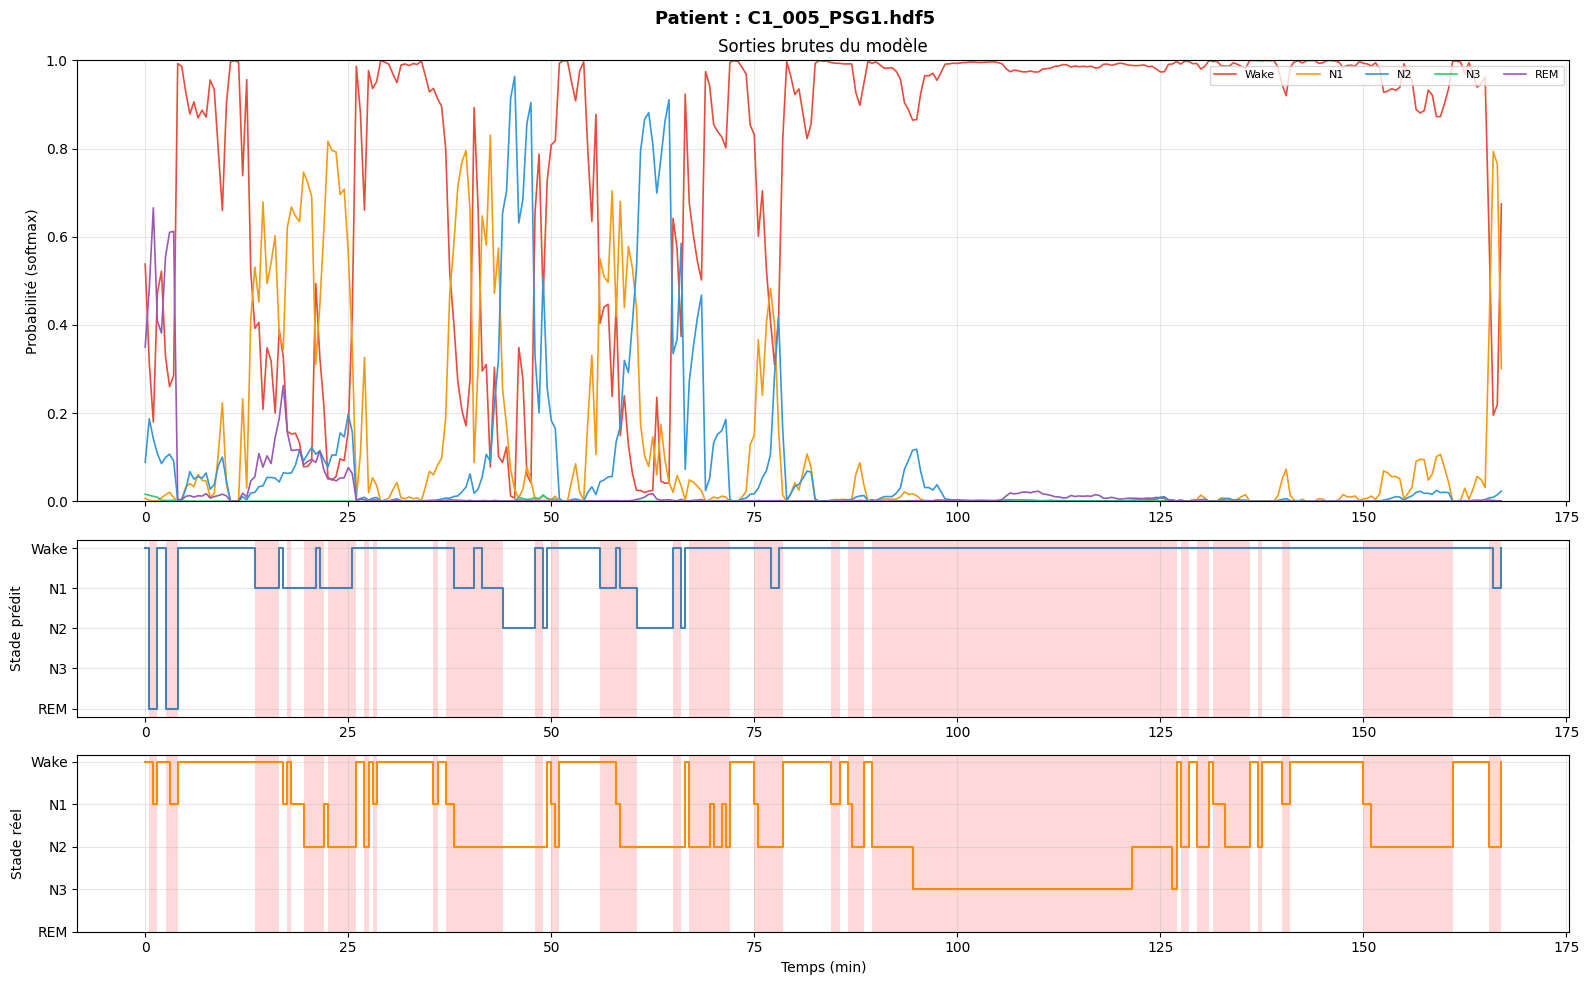


──────────────────────────────────────────────────
Patient : C1_005_PSG1.hdf5
  Epochs valides : 335
  Accuracy       : 41.5%
  Distribution labels  : {'Wake': 128, 'N1': 27, 'N2': 125, 'N3': 55}
  Distribution prédits : {'Wake': 267, 'N1': 44, 'N2': 19, 'REM': 5}
torch.Size([5, 4, 2160, 128]) torch.Size([5, 360]) torch.Size([5, 4, 2160])
Logits shape: torch.Size([5, 360]), Mask shape: torch.Size([5, 2160])


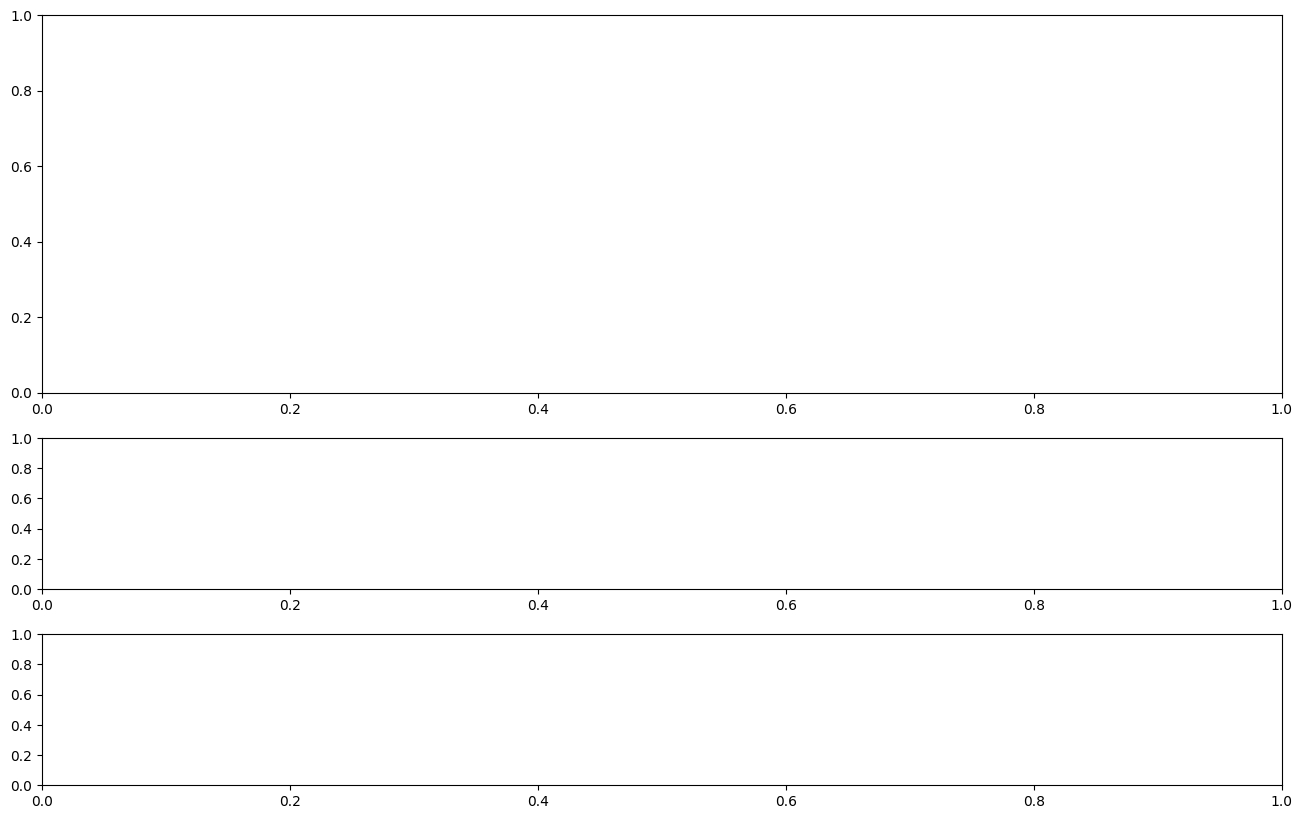

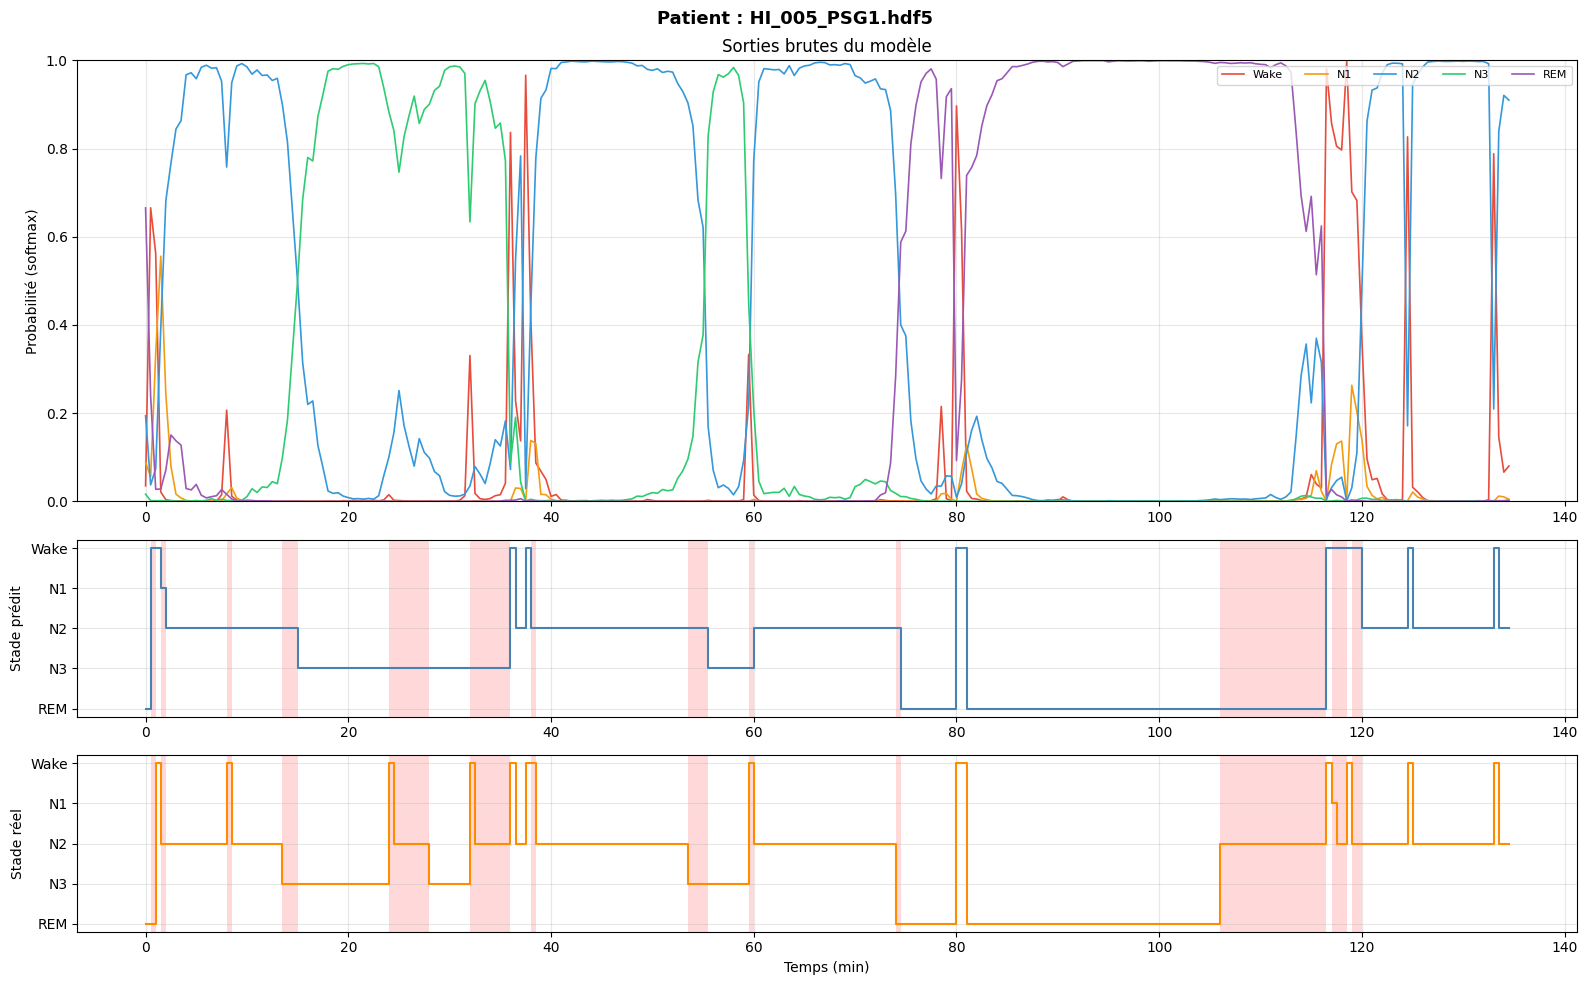


──────────────────────────────────────────────────
Patient : HI_005_PSG1.hdf5
  Epochs valides : 270
  Accuracy       : 79.6%
  Distribution labels  : {'Wake': 14, 'N1': 1, 'N2': 150, 'N3': 41, 'REM': 64}
  Distribution prédits : {'Wake': 15, 'N1': 1, 'N2': 120, 'N3': 51, 'REM': 83}


KeyboardInterrupt: 

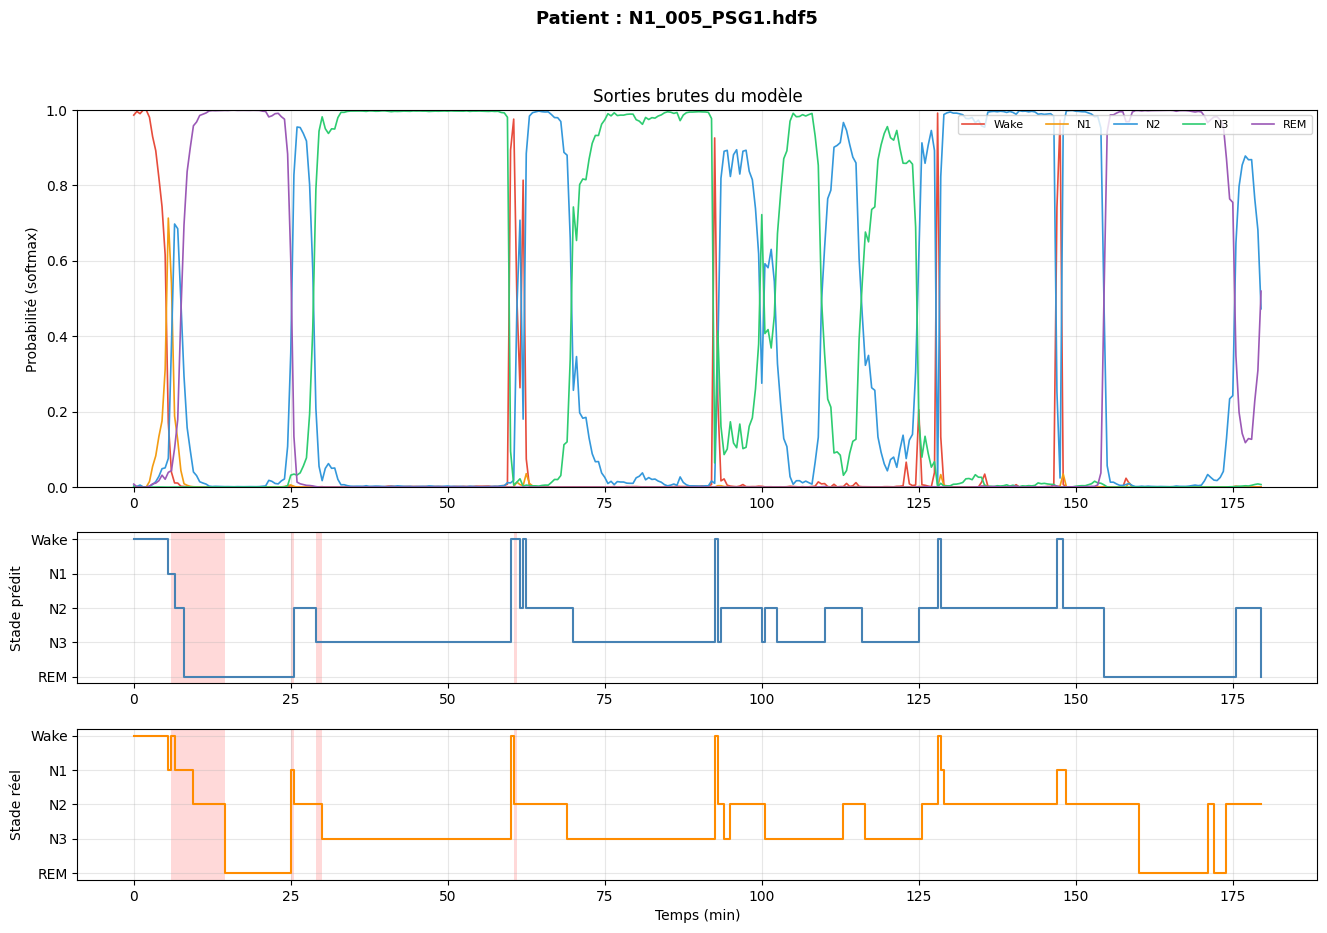

In [37]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

STAGE_NAMES = {0: "Wake", 1: "N1", 2: "N2", 3: "N3", 4: "REM"}
COLORS      = {0: "#e74c3c", 1: "#f39c12", 2: "#3498db", 3: "#2ecc71", 4: "#9b59b6"}

def inspect_model_output(model, dataloader, device, n_samples=6):
    """
    Affiche pour n_samples patients :
      - Les probabilités brutes (softmax) par classe au fil du temps
      - La comparaison prédiction vs label epoch par epoch
    """
    val= n_samples//3
    model.eval()
    samples_shown = 0
    test = [0, 0, 0]
    with torch.no_grad():
        for x_batch, y_batch, mask_batch, paths in dataloader:
            print(x_batch.shape, y_batch.shape, mask_batch.shape)
            x_batch   = x_batch.to(device)
            y_batch   = y_batch.to(device)
            mask_batch = mask_batch.to(device)

            outputs = model(x_batch, mask_batch)

            # Unpack output (même logique que ton validate)
            if isinstance(outputs, tuple):
                logits, *_, mask_temporal = outputs
            else:
                logits = outputs
                mask_temporal = mask_batch[:, 0, :]
            print(f"Logits shape: {y_batch.shape}, Mask shape: {mask_temporal.shape}")
            B, T, C = logits.shape
            assert T % 6 == 0, f"T={T} n'est pas multiple de 6"

            logits = logits.view(B, T // 6, 6, C).mean(dim=2)   # [B, T30, C]

            if mask_temporal.dim() == 2:
                mask_temporal = mask_temporal[:, :T].contiguous()
                mask_temporal = mask_temporal.view(B, T // 6, 6)
                mask_temporal = mask_temporal.max(dim=2).values   # [B, T30]
                    
            probs = torch.softmax(logits, dim=-1)  # (B, T, n_classes)
            preds = torch.argmax(logits, dim=-1)   # (B, T)
            for i in range(x_batch.shape[0]):
                if samples_shown >= n_samples:
                    return

                mask_i   = mask_temporal[i].cpu().numpy()        # (T,)
                valid     = mask_i == 0                          # epochs valides

                probs_i  = probs[i].cpu().numpy()[valid]         # (T_valid, n_classes)
                preds_i  = preds[i].cpu().numpy()[valid]         # (T_valid,)
                labels_i = y_batch[i].cpu().numpy()[valid]       # (T_valid,)
                n_epochs  = len(labels_i)
                time_axis = np.arange(n_epochs) * 30 / 60        # en minutes

                fig, axes = plt.subplots(3, 1, figsize=(16, 10),
                                         gridspec_kw={'height_ratios': [2.5, 1, 1]})
                patient_name = os.path.basename(paths[i])
                if patient_name.startswith("C1"):
                    if test[0] == val:
                        break
                    test[0] += 1
                if patient_name.startswith("N1"):
                    if test[1] == val:
                        break
                    test[1] += 1
                if patient_name.startswith("HI"):
                    if test[2] == val:
                        break
                    test[2] += 1
                fig.suptitle(f"Patient : {patient_name}", fontsize=13, fontweight='bold')

                # ── 1. Probabilités brutes ──────────────────────────────────────
                ax = axes[0]
                for cls in range(probs_i.shape[1]):
                    ax.plot(time_axis, probs_i[:, cls],
                            label=STAGE_NAMES.get(cls, str(cls)),
                            color=COLORS.get(cls, "gray"), linewidth=1.2)
                ax.set_ylabel("Probabilité (softmax)")
                ax.set_title("Sorties brutes du modèle")
                ax.legend(loc="upper right", ncol=5, fontsize=8)
                ax.set_ylim(0, 1)
                ax.grid(alpha=0.3)

                # ── 2. Hypnogramme prédit ───────────────────────────────────────
                ax = axes[1]
                ax.step(time_axis, preds_i, where='post',
                        color='steelblue', linewidth=1.5, label="Prédit")
                ax.set_yticks(list(STAGE_NAMES.keys()))
                ax.set_yticklabels([STAGE_NAMES[k] for k in STAGE_NAMES])
                ax.set_ylabel("Stade prédit")
                ax.invert_yaxis()
                ax.grid(alpha=0.3)

                # ── 3. Hypnogramme label (vérité terrain) ──────────────────────
                ax = axes[2]
                ax.step(time_axis, labels_i, where='post',
                        color='darkorange', linewidth=1.5, label="Label")
                ax.set_yticks(list(STAGE_NAMES.keys()))
                ax.set_yticklabels([STAGE_NAMES[k] for k in STAGE_NAMES])
                ax.set_ylabel("Stade réel")
                ax.set_xlabel("Temps (min)")
                ax.invert_yaxis()
                ax.grid(alpha=0.3)

                # ── Colorier les erreurs en rouge ───────────────────────────────
                for t in range(n_epochs - 1):
                    if preds_i[t] != labels_i[t]:
                        for a in axes[1:]:
                            a.axvspan(time_axis[t], time_axis[t+1],
                                      alpha=0.15, color='red', linewidth=0)

                plt.tight_layout()
                plt.show()

                # ── Stats rapides en console ────────────────────────────────────
                acc = (preds_i == labels_i).mean()
                print(f"\n{'─'*50}")
                print(f"Patient : {patient_name}")
                print(f"  Epochs valides : {n_epochs}")
                print(f"  Accuracy       : {acc:.1%}")
                print(f"  Distribution labels  : { {STAGE_NAMES[k]: int((labels_i==k).sum()) for k in STAGE_NAMES if (labels_i==k).any()} }")
                print(f"  Distribution prédits : { {STAGE_NAMES[k]: int((preds_i==k).sum()) for k in STAGE_NAMES if (preds_i==k).any()} }")

                samples_shown += 1



inspect_model_output(sleep_staging_model2, val_loader, device, n_samples=3)

In [30]:

def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    accumulation_steps = config.get('accumulation_steps', 1)
    gradient_clip = config.get('gradient_clip', 1.0)
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1} [Train]", leave=False)
    optimizer.zero_grad()

    for batch_idx, (x_batch, y_batch, mask_batch, paths) in enumerate(pbar):

        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        mask_batch = mask_batch.to(device, non_blocking=True)
        outputs = model(x_batch, mask_batch)
        if isinstance(outputs, tuple):
            if len(outputs) == 3:
                logits, _, mask_temporal = outputs
            else:
                logits, mask_temporal = outputs
        else:
            logits = outputs
            mask_temporal = mask_batch[:, 0, :]
        B, T, C = logits.shape
        assert T % 6 == 0, f"T={T} n'est pas multiple de 6"

        logits = logits.view(B, T // 6, 6, C).mean(dim=2)   # [B, T30, C]

        if mask_temporal.dim() == 2:
            mask_temporal = mask_temporal[:, :T].contiguous()
            mask_temporal = mask_temporal.view(B, T // 6, 6)
            mask_temporal = mask_temporal.max(dim=2).values   # [B, T30]
        loss = criterion(logits, y_batch, mask_temporal)
        loss = loss / accumulation_steps
        loss.backward()
        if (batch_idx + 1) % accumulation_steps == 0:
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
            optimizer.step()
            optimizer.zero_grad()
        total_loss += loss.item() * accumulation_steps
        
        with torch.no_grad():
            preds = torch.argmax(logits, dim=-1)
            mask_flat = mask_temporal.cpu().numpy().flatten()
            preds_flat = preds.cpu().numpy().flatten()
            labels_flat = y_batch.cpu().numpy().flatten()
            
            valid_idx = mask_flat == 0
            all_preds.extend(preds_flat[valid_idx])
            all_labels.extend(labels_flat[valid_idx])
        pbar.set_postfix({'loss': f"{loss.item() * accumulation_steps:.4f}"})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    return avg_loss, accuracy, f1_macro, f1_weighted

def validate(model, dataloader, criterion, device, epoch):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1} [Val]", leave=False)
        
        for x_batch, y_batch, mask_batch, paths in pbar:
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            mask_batch = mask_batch.to(device, non_blocking=True)
            
            outputs = model(x_batch, mask_batch)
            
            if isinstance(outputs, tuple):
                if len(outputs) == 3:
                    logits, _, mask_temporal = outputs
                else:
                    logits, mask_temporal = outputs
            else:
                logits = outputs
                mask_temporal = mask_batch[:, 0, :]
            B, T, C = logits.shape
            assert T % 6 == 0, f"T={T} n'est pas multiple de 6"

            logits = logits.view(B, T // 6, 6, C).mean(dim=2)   # [B, T30, C]

            if mask_temporal.dim() == 2:
                mask_temporal = mask_temporal[:, :T].contiguous()
                mask_temporal = mask_temporal.view(B, T // 6, 6)
                mask_temporal = mask_temporal.max(dim=2).values   # [B, T30]
            loss = criterion(logits, y_batch, mask_temporal)
            total_loss += loss.item()
            
            preds = torch.argmax(logits, dim=-1)
            mask_flat = mask_temporal.cpu().numpy().flatten()
            preds_flat = preds.cpu().numpy().flatten()
            labels_flat = y_batch.cpu().numpy().flatten()
            
            valid_idx = mask_flat == 0
            all_preds.extend(preds_flat[valid_idx])
            all_labels.extend(labels_flat[valid_idx])
            
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    return avg_loss, accuracy, f1_macro, f1_weighted, all_preds, all_labels

def plotter(history, log_dir, best_val_f1):
    print(f"\n{'='*60}")
    print(f"✅ ENTRAÎNEMENT TERMINÉ")
    print(f"{'='*60}")

    print(f"\n📈 Meilleur résultat:")
    print(f"   Val F1-Macro: {best_val_f1:.4f}")

    print(f"\n📊 Progression:")
    print(f"   Epoch   1: Train Acc={history['train_acc'][0]:.3f}, Val Acc={history['val_acc'][0]:.3f}")
    print(f"   Epoch  50: Train Acc={history['train_acc'][49]:.3f}, Val Acc={history['val_acc'][49]:.3f}") if len(history['train_acc']) >= 50 else None
    print(f"   Epoch 100: Train Acc={history['train_acc'][-1]:.3f}, Val Acc={history['val_acc'][-1]:.3f}")
        
    import matplotlib.pyplot as plt

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss
    ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
    ax1.plot(history['val_loss'], label='Val Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss over epochs')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy
    ax2.plot(history['train_acc'], label='Train Acc', linewidth=2)
    ax2.plot(history['val_acc'], label='Val Acc', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy over epochs')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(log_dir, 'overfit_curves.png'), dpi=150)
    print(f"\n✅ Graphiques sauvegardés: {os.path.join(log_dir, 'overfit_curves.png')}")
    plt.show()

    # ============================================================
    # DIAGNOSTIC
    # ============================================================

    print(f"\n🔍 DIAGNOSTIC:")

    final_train_acc = history['train_acc'][-1]
    final_val_acc = history['val_acc'][-1]

    if final_train_acc > 0.95 and final_val_acc > 0.95:
        print(f"   ✅✅✅ EXCELLENT ! Le modèle peut overfitter")
        print(f"       → Le modèle FONCTIONNE et peut apprendre")
        print(f"       → Le problème vient de l'alignement ou du dataset complet")
    elif final_train_acc > 0.70:
        print(f"   ✅ BON ! Le modèle apprend")
        print(f"       → Peut-être besoin de plus d'epochs ou LR plus élevé")
    elif final_train_acc > 0.40:
        print(f"   ⚠️ MOYEN. Le modèle apprend lentement")
        print(f"       → Vérifier le format d'entrée ou l'architecture")
    else:
        print(f"   ❌ PROBLÈME ! Le modèle n'apprend pas")
        print(f"       → Format d'entrée incorrect")
        print(f"       → Poids frozen")
        print(f"       → Bug dans le forward pass")

    print(f"\n{'='*60}")
    

In [31]:
from glob import glob
base_data_path_emb = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_downsampling\\train_emb_test"
base_data_path = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_downsampling"
base_save_path = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\save"

def training(config_ent, sleep_staging_model, base_data_path_emb, base_data_path, base_save_path, train_one_epoch= train_one_epoch, validate=validate, criterion= criterion, checkpoint = False, checkpoint_path = None, plotter_bool=True):

    if checkpoint and checkpoint_path is not None:
        if os.path.exists(checkpoint_path):
            print(f"\n Chargement du checkpoint: {checkpoint_path}")
            
            checkpoint = torch.load(checkpoint_path, map_location=device)
    
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        else:
            state_dict = checkpoint
    
        new_state_dict = {}
        for k, v in state_dict.items():
            new_key = k.replace('module.', '')
            new_state_dict[new_key] = v
        
        # Charger (strict=False car votre architecture peut différer)
        sleep_staging_model.load_state_dict(new_state_dict, strict=False)
        print(" Checkpoint chargé")
    else:
        print(f"\n  Aucun checkpoint trouvé à {checkpoint_path}")
        print("   Le modèle sera entraîné depuis zéro")
    checkpoint_dir = os.path.join(base_save_path, "checkpoints")
    log_dir = os.path.join(base_save_path, "logs")
    os.makedirs(checkpoint_dir, exist_ok=True)
    os.makedirs(log_dir, exist_ok=True)

    # Sauvegarder la config
    with open(os.path.join(checkpoint_dir, "config.json"), 'w') as f:
        json.dump(config_ent, f, indent=4)

    print(f" Checkpoints: {checkpoint_dir}")
    print(f" Logs: {log_dir}")
    hdf5_files = glob(os.path.join(base_data_path_emb, "*.hdf5"))

    file_pairs = []

    for hdf5_path in hdf5_files:
        # Extraire le nom de base (ex: C1_012_PSG1)
        hdf5_basename = os.path.basename(hdf5_path).replace('.hdf5', '')

        csv_pattern = f"{hdf5_basename}.csv"
        csv_path = os.path.join(base_data_path, csv_pattern)
        if os.path.exists(csv_path):
            file_pairs.append((hdf5_path, csv_path))
        else:
            print(f"CSV manquant pour: {hdf5_basename}")
            print(f"Cherché: {csv_pattern}")

    print(f"\n Total de paires HDF5-CSV: {len(file_pairs)}")

    """train_pairs = file_pairs[: int(len(file_pairs)*0.8)]  
    val_pairs = file_pairs[int(len(file_pairs)*0.8):len(file_pairs)]   
    # Séparer les chemins
    train_hdf5 = [pair[0] for pair in train_pairs]
    train_labels = [pair[1] for pair in train_pairs]

    val_hdf5 = [pair[0] for pair in val_pairs]
    val_labels = [pair[1] for pair in val_pairs]"""
    train_hdf5 = []
    train_labels = []
    val_hdf5 = []
    val_labels = []
    val = [0,0,0]
    for i,j in file_pairs:
        hdf5_basename = os.path.basename(i).replace('.hdf5', '')
        if hdf5_basename.startswith("C1"):
            if val[0] <= 3:
                val[0] += 1
                train_hdf5.append(i)
                train_labels.append(j)
            else:
                val_hdf5.append(i)
                val_labels.append(j)
        elif hdf5_basename.startswith("N1"):
            if val[1] <= 3:
                val[1] += 1
                train_hdf5.append(i)
                train_labels.append(j)
            else:
                val_hdf5.append(i)
                val_labels.append(j)
        elif hdf5_basename.startswith("HI"):
            if val[2] <= 3:
                val[2] += 1
                train_hdf5.append(i)
                train_labels.append(j)
            else:
                val_hdf5.append(i)
                val_labels.append(j)
    # CRÉER LES DATASETS
    print(train_hdf5, train_labels)
    print("\n")
    print(val_hdf5, val_labels)
    train_dataset = SleepEventClassificationDataset(
        config_ent, 
        CHANNEL_GROUPS_FOR_MODEL, 
        split="train", 
        hdf5_paths=train_hdf5, 
        label_files=train_labels
    )
    

    val_dataset = SleepEventClassificationDataset(
        config_ent, 
        CHANNEL_GROUPS_FOR_MODEL, 
        split="val", 
        hdf5_paths=val_hdf5, 
        label_files=val_labels
    )

    print(f"\n📊 Datasets créés:")
    print(f"   Train: {len(train_dataset)} échantillons")
    print(f"   Val:   {len(val_dataset)} échantillons")

    if len(train_dataset) == 0:
        print("\n❌ ERREUR: Le dataset train est vide!")
        print("   Vérifiez que les noms de fichiers HDF5 et CSV correspondent")
        # Afficher les noms exacts
        print("\n🔍 Vérification des noms:")
        for hdf5 in train_hdf5:
            basename = os.path.basename(hdf5).replace('.hdf5', '')
            print(f"   HDF5 basename: '{basename}'")
        for csv in train_labels:
            basename = os.path.basename(csv).replace('PSG4_Hypnogram_Export_', '').replace('.csv', '')
            print(f"   CSV basename: '{basename}'")
        
    #  DATALOADERS

    train_loader = DataLoader(
        train_dataset,
        batch_size=config_ent['batch_size'],
        shuffle=True,
        num_workers=0,  
        collate_fn=sleep_event_finetune_full_collate_fn,
        pin_memory=True if torch.cuda.is_available() else False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=config_ent['batch_size'],
        shuffle=False,
        num_workers=0,
        collate_fn=sleep_event_finetune_full_collate_fn,
        pin_memory=True if torch.cuda.is_available() else False
    )
        # Test d'un batch
    print("\n🔍 Test d'alignement X/Y:")
    optimizer = optim.AdamW(
        sleep_staging_model.parameters(),
        lr=config_ent['lr'],
        weight_decay=config_ent.get('weight_decay', 1e-5)
    )
    best_val_loss = float('inf')
    best_val_f1 = 0.0
    patience_counter = 0
    patience = config_ent.get('patience', 10)

    history = {
        'train_loss': [], 'train_acc': [], 'train_f1_macro': [], 'train_f1_weighted': [],
        'val_loss': [], 'val_acc': [], 'val_f1_macro': [], 'val_f1_weighted': [],
        'learning_rates': []
    }

    num_epochs = config_ent['epochs']
    for epoch in range(num_epochs):
        print(f" Epoch {epoch+1}/{num_epochs}")
        
        # Train
        train_loss, train_acc, train_f1_macro, train_f1_weighted = train_one_epoch(
            sleep_staging_model, train_loader, criterion, optimizer, device, epoch
        )
        # Validate
        val_loss, val_acc, val_f1_macro, val_f1_weighted, val_preds, val_labels = validate(
            sleep_staging_model, val_loader, criterion, device, epoch
        )
        
        current_lr = optimizer.param_groups[0]['lr']
        
        # History
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1_macro'].append(train_f1_macro)
        history['train_f1_weighted'].append(train_f1_weighted)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1_macro'].append(val_f1_macro)
        history['val_f1_weighted'].append(val_f1_weighted)
        history['learning_rates'].append(current_lr)
        
        # Print
        """print(f"\n Résultats:")
        print(f"   Train - Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1-Macro: {train_f1_macro:.4f}")
        print(f"   Val   - Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1-Macro: {val_f1_macro:.4f}")
        print(f"   LR: {current_lr:.2e}")"""
        
        # Best model
        is_best = val_f1_macro > best_val_f1
        
        if is_best:
            best_val_loss = val_loss
            best_val_f1 = val_f1_macro
            patience_counter = 0
            
            checkpoint = {
                'epoch': epoch + 1,
                'model_state_dict': sleep_staging_model.module.state_dict() if isinstance(sleep_staging_model, nn.DataParallel) else sleep_staging_model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_f1_macro': val_f1_macro,
                'config': config_ent,
                'history': history
            }
            
            torch.save(checkpoint, os.path.join(checkpoint_dir, 'best2.pth'))
            print(f"\n Meilleur modèle sauvegardé (F1: {val_f1_macro:.4f})")  
            
        else:
            patience_counter += 1
            """print(f"\n Patience: {patience_counter}/{patience}")"""
        
        if (epoch + 1) % 100 == 0:
            print(f"\n📊 Epoch {epoch+1} - Rapport détaillé:")
            print(f"Labels: {len(val_labels)} dimensions")
            print(f"Prédictions: {len(val_preds)} dimensions")
            print(len(val_labels), len(val_preds))
            print(classification_report(
                val_labels, val_preds,
                labels=[0, 1, 2, 3, 4],
                target_names=['Wake', 'REM', 'N1', 'N2', 'N3'],
                digits=3,
                zero_division=0
            ))
            
        # Early stopping
        if patience_counter >= patience:
            print(f"\n Early stopping")
            break

    print("\n ENTRAÎNEMENT TERMINÉ")
    print(f" Meilleur F1-Macro: {best_val_f1:.4f}")
    if plotter_bool:
        plotter(history, log_dir, best_val_f1)
    return history, log_dir, best_val_f1,val_loader



  Aucun checkpoint trouvé à C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save_down\checkpoints\best.pth
   Le modèle sera entraîné depuis zéro
 Checkpoints: C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save\checkpoints
 Logs: C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save\logs

 Total de paires HDF5-CSV: 15
['C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_downsampling\\train_emb_test\\C1_001_PSG1.hdf5', 'C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_downsampling\\train_emb_test\\C1_002_PSG1.hdf5', 'C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_downsampling\\train_emb_test\\C1_003_PSG1.hdf5', 'C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\sleep_fm\\sleepfm-clinical\\notebooks\\train_downsampling\\train_emb_test\\C1_004_PSG1.hdf5', 'C:\\Users\\gab

Indexing val data: 100%|██████████| 3/3 [00:00<00:00, 732.33it/s]



📊 Datasets créés:
   Train: 44 échantillons
   Val:   10 échantillons

🔍 Test d'alignement X/Y:
 Epoch 1/200



 Meilleur modèle sauvegardé (F1: 0.5799)
 Epoch 2/200



 Meilleur modèle sauvegardé (F1: 0.5890)
 Epoch 3/200


...

 Epoch 14/200


 Epoch 15/200


 Epoch 16/200


 Epoch 17/200



 Early stopping

 ENTRAÎNEMENT TERMINÉ
 Meilleur F1-Macro: 0.6509

✅ ENTRAÎNEMENT TERMINÉ

📈 Meilleur résultat:
   Val F1-Macro: 0.6509

📊 Progression:
   Epoch   1: Train Acc=0.529, Val Acc=0.649
   Epoch 100: Train Acc=0.899, Val Acc=0.751

✅ Graphiques sauvegardés: C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save\logs\overfit_curves.png


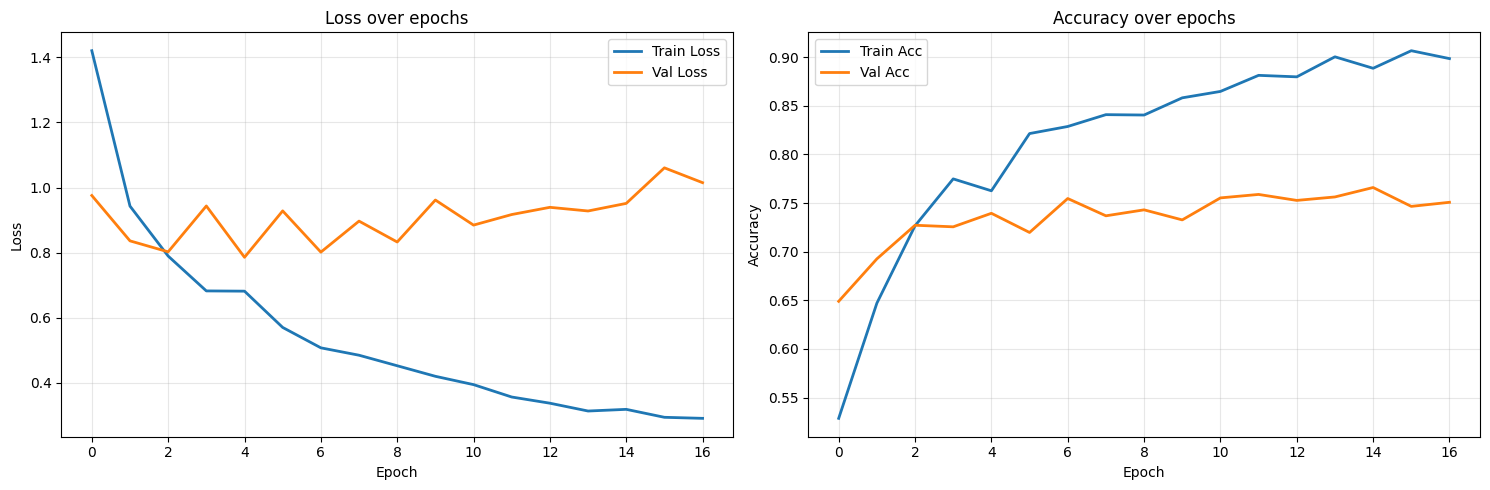


🔍 DIAGNOSTIC:
   ✅ BON ! Le modèle apprend
       → Peut-être besoin de plus d'epochs ou LR plus élevé



In [32]:
history, log_dir, best_val_f1,val_loader = training(config_ent, sleep_staging_model2,base_data_path_emb, base_data_path, base_save_path, train_one_epoch, validate, criterion, checkpoint=False, checkpoint_path=checkpoint_path, plotter_bool=True)



📊 GÉNÉRATION MATRICE DE CONFUSION FINALE

🔄 Calcul des prédictions finales...


Validation: 100%|██████████| 2/2 [00:00<00:00,  6.93it/s]


✅ 3094 prédictions collectées

📊 Matrice de confusion (nombres absolus):
           Prédit →
   Vrai ↓    Wake     REM      N1      N2      N3
   --------------------------------------------------
   Wake      325      16      32      10       5
   REM        35       9      31       0      13
   N1        117      52     950      70      80
   N2         60       0     218     504       0
   N3          3       6      23       0     535

📊 Matrice de confusion (pourcentages - Recall par classe):
           Prédit →
   Vrai ↓    Wake     REM      N1      N2      N3
   --------------------------------------------------
   Wake    83.8%    4.1%    8.2%    2.6%    1.3%
   REM     39.8%   10.2%   35.2%    0.0%   14.8%
   N1       9.2%    4.1%   74.9%    5.5%    6.3%
   N2       7.7%    0.0%   27.9%   64.5%    0.0%
   N3       0.5%    1.1%    4.1%    0.0%   94.4%

✅ Matrice de confusion sauvegardée: C:\Users\gabri\Desktop\stage_sommeil\algo\sleep_fm\sleepfm-clinical\notebooks\save\logs\conf

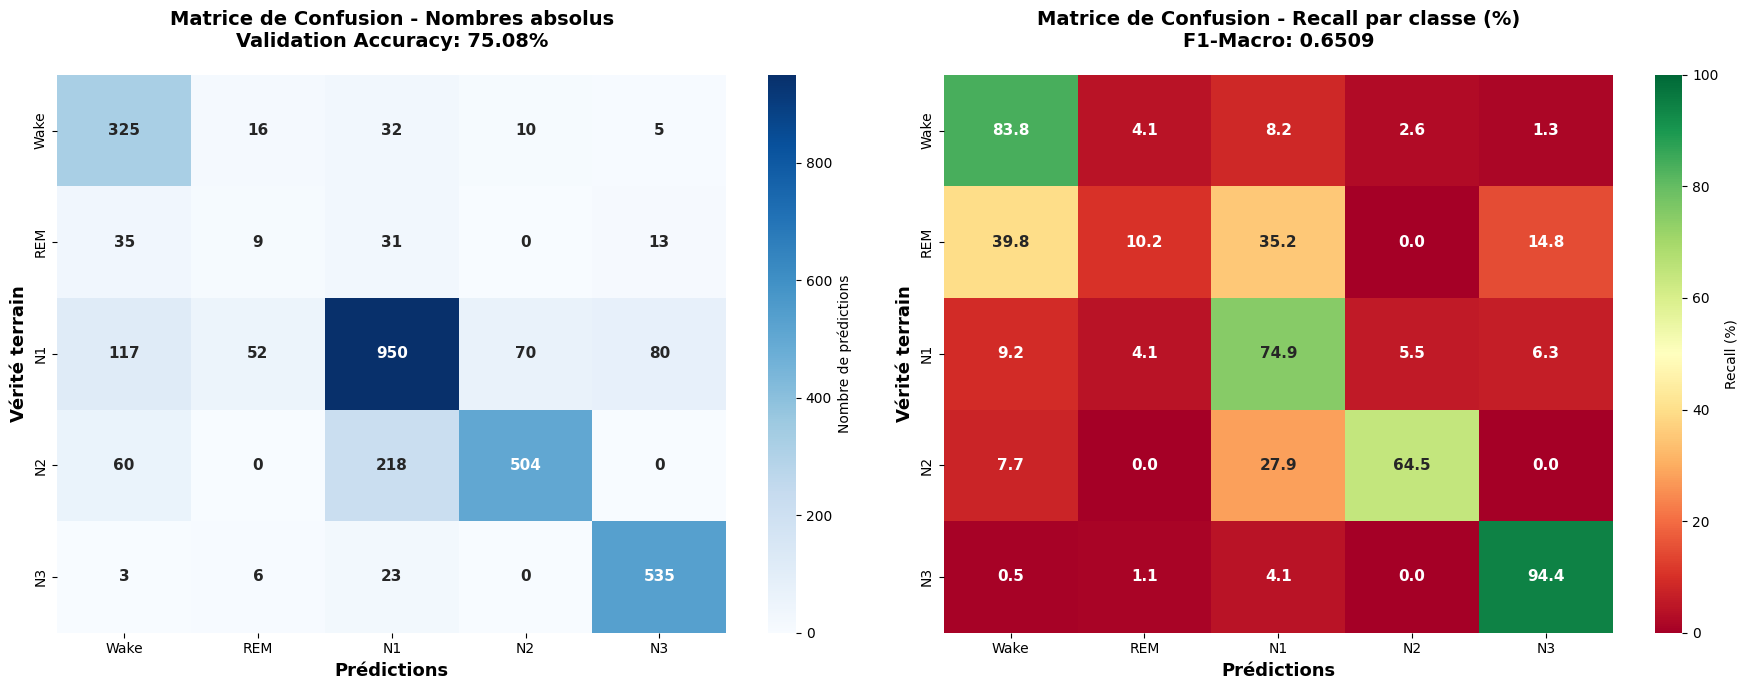


📈 MÉTRIQUES DÉTAILLÉES PAR CLASSE

Classe    Support  Precision     Recall   F1-Score
--------------------------------------------------
Wake          388      0.602      0.838      0.700
REM            88      0.108      0.102      0.105
N1           1269      0.758      0.749      0.753
N2            782      0.863      0.645      0.738
N3            567      0.845      0.944      0.892
--------------------------------------------------
Macro                  0.635      0.655      0.638
Weighted               0.762      0.751      0.750

🔍 TOP 5 DES CONFUSIONS
  1.   218× N2   → N1   ( 27.9% des N2)
  2.   117× N1   → Wake (  9.2% des N1)
  3.    80× N1   → N3   (  6.3% des N1)
  4.    70× N1   → N2   (  5.5% des N1)
  5.    60× N2   → Wake (  7.7% des N2)



In [33]:
def plot_final_confusion_matrix(sleep_staging_model, val_loader, device, log_dir, best_val_f1):
    """
    📊 Créer et sauvegarder la matrice de confusion finale
    """
    
    print("\n" + "="*60)
    print("📊 GÉNÉRATION MATRICE DE CONFUSION FINALE")
    print("="*60)
    
    # ============================================================
    # OBTENIR LES PRÉDICTIONS FINALES
    # ============================================================
    
    sleep_staging_model.eval()
    
    all_preds = []
    all_labels = []
    
    print("\n🔄 Calcul des prédictions finales...")
    
    with torch.no_grad():
        for x_batch, y_batch, mask_batch, paths in tqdm(val_loader, desc="Validation"):
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            mask_batch = mask_batch.to(device)
            
            # Forward
            outputs = sleep_staging_model(x_batch, mask_batch)
            
            if isinstance(outputs, tuple):
                logits = outputs[0]
                mask_temporal = outputs[-1] if len(outputs) >= 2 else mask_batch[:, 0, :]
            else:
                logits = outputs
                mask_temporal = mask_batch[:, 0, :]
            B, T, C = logits.shape
            assert T % 6 == 0, f"T={T} n'est pas multiple de 6"

            logits = logits.view(B, T // 6, 6, C).mean(dim=2)   # [B, T30, C]

            if mask_temporal.dim() == 2:
                mask_temporal = mask_temporal[:, :T].contiguous()
                mask_temporal = mask_temporal.view(B, T // 6, 6)
                mask_temporal = mask_temporal.max(dim=2).values   # [B, T30]
            # Prédictions
            preds = torch.argmax(logits, dim=-1)
            
            # Filtrer les éléments valides
            if mask_temporal.dtype == torch.bool:
                valid_idx = (~mask_temporal).cpu().numpy().flatten()
            else:
                valid_idx = (mask_temporal == 0).cpu().numpy().flatten()
            
            preds_flat = preds.cpu().numpy().flatten()
            labels_flat = y_batch.cpu().numpy().flatten()
            
            all_preds.extend(preds_flat[valid_idx])
            all_labels.extend(labels_flat[valid_idx])
    
    print(f"✅ {len(all_labels)} prédictions collectées")
    
    # ============================================================
    # CALCULER LA MATRICE DE CONFUSION
    # ============================================================
    
    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2, 3, 4])
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    stage_names = ['Wake', 'REM', 'N1', 'N2', 'N3']
    
    # ============================================================
    # AFFICHAGE TEXTUEL
    # ============================================================
    
    print(f"\n📊 Matrice de confusion (nombres absolus):")
    print(f"           Prédit →")
    print(f"   Vrai ↓  {'  '.join([f'{name:>6s}' for name in stage_names])}")
    print(f"   {'-'*50}")
    for i, name in enumerate(stage_names):
        row_str = '  '.join([f'{val:6d}' for val in cm[i]])
        print(f"   {name:4s}   {row_str}")
    
    print(f"\n📊 Matrice de confusion (pourcentages - Recall par classe):")
    print(f"           Prédit →")
    print(f"   Vrai ↓  {'  '.join([f'{name:>6s}' for name in stage_names])}")
    print(f"   {'-'*50}")
    for i, name in enumerate(stage_names):
        row_str = '  '.join([f'{val:5.1f}%' for val in cm_percent[i]])
        print(f"   {name:4s}   {row_str}")
    
    # ============================================================
    # VISUALISATION GRAPHIQUE
    # ============================================================
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Matrice 1 : Nombres absolus
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        xticklabels=stage_names, 
        yticklabels=stage_names,
        cbar_kws={'label': 'Nombre de prédictions'},
        ax=axes[0],
        annot_kws={'fontsize': 11, 'fontweight': 'bold'}
    )
    axes[0].set_xlabel('Prédictions', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Vérité terrain', fontsize=13, fontweight='bold')
    axes[0].set_title(
        f'Matrice de Confusion - Nombres absolus\nValidation Accuracy: {np.trace(cm)/cm.sum():.2%}', 
        fontsize=14, 
        fontweight='bold',
        pad=20
    )
    
    # Matrice 2 : Pourcentages (Recall)
    sns.heatmap(
        cm_percent, 
        annot=True, 
        fmt='.1f', 
        cmap='RdYlGn',
        xticklabels=stage_names, 
        yticklabels=stage_names,
        cbar_kws={'label': 'Recall (%)'},
        vmin=0, 
        vmax=100,
        ax=axes[1],
        annot_kws={'fontsize': 11, 'fontweight': 'bold'}
    )
    axes[1].set_xlabel('Prédictions', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Vérité terrain', fontsize=13, fontweight='bold')
    axes[1].set_title(
        f'Matrice de Confusion - Recall par classe (%)\nF1-Macro: {best_val_f1:.4f}', 
        fontsize=14, 
        fontweight='bold',
        pad=20
    )
    
    # Ajuster layout
    plt.tight_layout()
    
    # Sauvegarder
    save_path = os.path.join(log_dir, 'confusion_matrix_final.png')
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    
    print(f"\n✅ Matrice de confusion sauvegardée: {save_path}")
    plt.show()
    
    # ============================================================
    # STATISTIQUES DÉTAILLÉES
    # ============================================================
    
    from sklearn.metrics import precision_recall_fscore_support
    
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels, all_preds, 
        labels=[0, 1, 2, 3, 4],
        zero_division=0
    )
    
    print(f"\n{'='*60}")
    print(f"📈 MÉTRIQUES DÉTAILLÉES PAR CLASSE")
    print(f"{'='*60}")
    print(f"\n{'Classe':<8s} {'Support':>8s} {'Precision':>10s} {'Recall':>10s} {'F1-Score':>10s}")
    print(f"{'-'*50}")
    
    for i, name in enumerate(stage_names):
        print(f"{name:<8s} {support[i]:>8d} {precision[i]:>10.3f} {recall[i]:>10.3f} {f1[i]:>10.3f}")
    
    print(f"{'-'*50}")
    print(f"{'Macro':8s} {'':<8s} {precision.mean():>10.3f} {recall.mean():>10.3f} {f1.mean():>10.3f}")
    print(f"{'Weighted':8s} {'':<8s} {np.average(precision, weights=support):>10.3f} {np.average(recall, weights=support):>10.3f} {np.average(f1, weights=support):>10.3f}")
    
    # ============================================================
    # ANALYSE DES ERREURS
    # ============================================================
    
    print(f"\n{'='*60}")
    print(f"🔍 TOP 5 DES CONFUSIONS")
    print(f"{'='*60}")
    
    # Trouver les confusions hors diagonale
    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0)
    
    confusions = []
    for i in range(5):
        for j in range(5):
            if i != j and cm[i, j] > 0:
                pct = cm[i, j] / cm[i].sum() * 100
                confusions.append((cm[i, j], pct, stage_names[i], stage_names[j]))
    
    confusions.sort(reverse=True)
    
    for rank, (count, pct, true_class, pred_class) in enumerate(confusions[:5], 1):
        print(f"  {rank}. {count:5d}× {true_class:4s} → {pred_class:4s} ({pct:5.1f}% des {true_class})")
    
    print(f"\n{'='*60}")
    
    return cm, cm_percent

cm, cm_percent = plot_final_confusion_matrix(
    sleep_staging_model=sleep_staging_model2,
    val_loader=val_loader,
    device=device,
    log_dir=log_dir,
    best_val_f1=best_val_f1
)

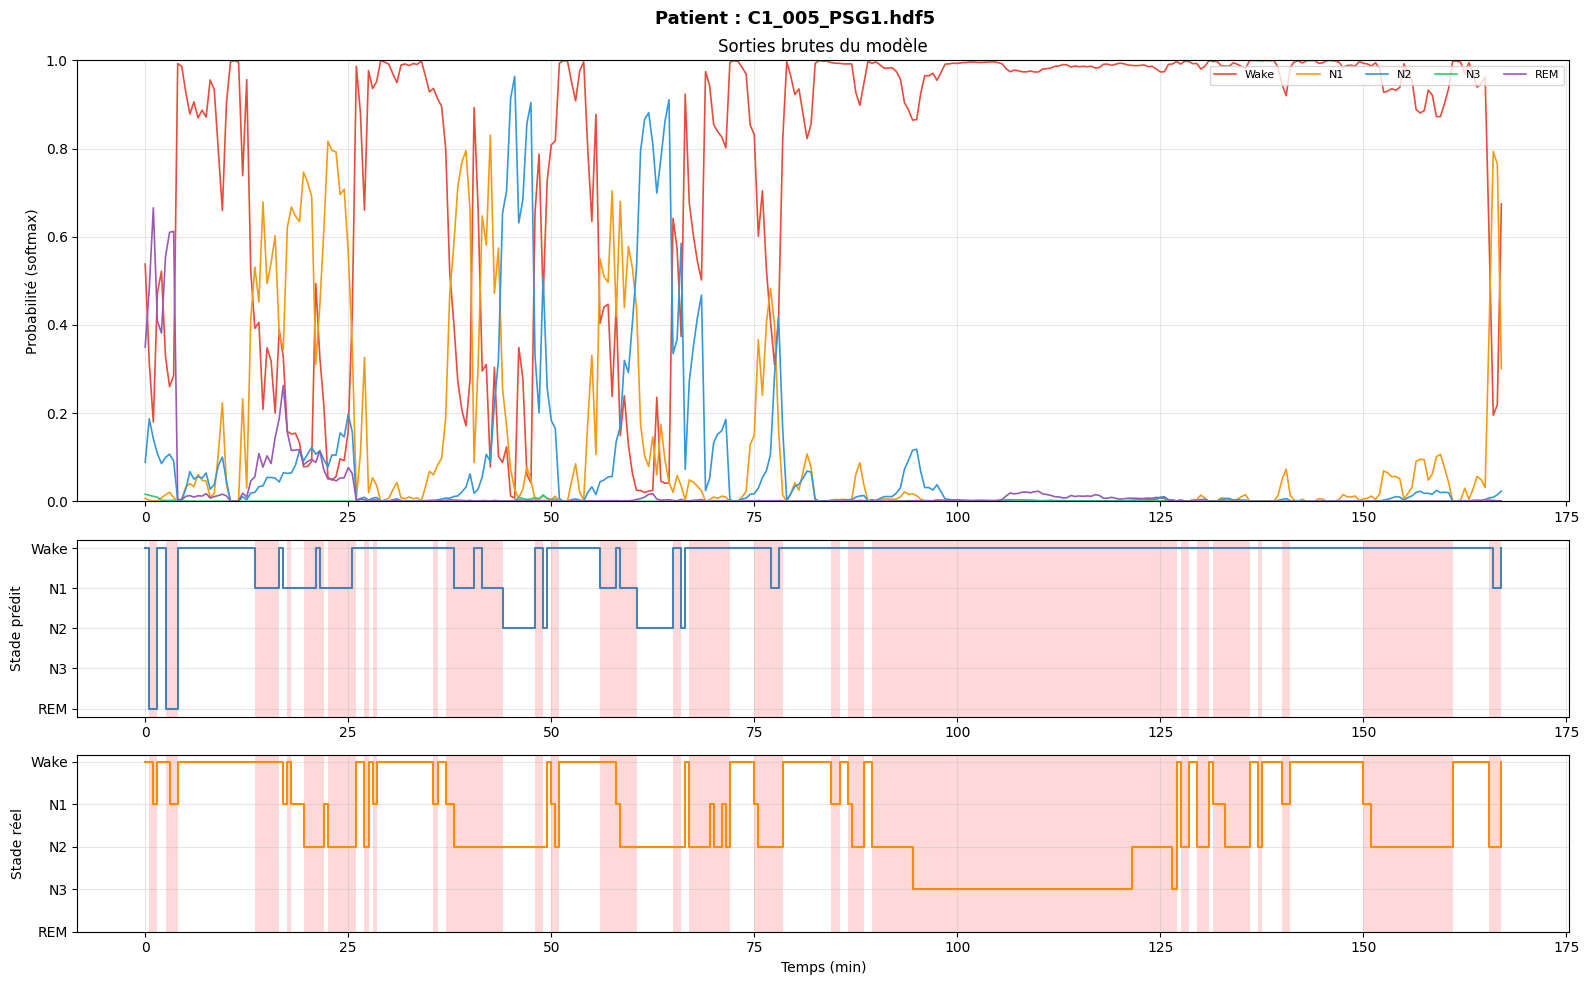


──────────────────────────────────────────────────
Patient : C1_005_PSG1.hdf5
  Epochs valides : 335
  Accuracy       : 41.5%
  Distribution labels  : {'Wake': 128, 'N1': 27, 'N2': 125, 'N3': 55}
  Distribution prédits : {'Wake': 267, 'N1': 44, 'N2': 19, 'REM': 5}


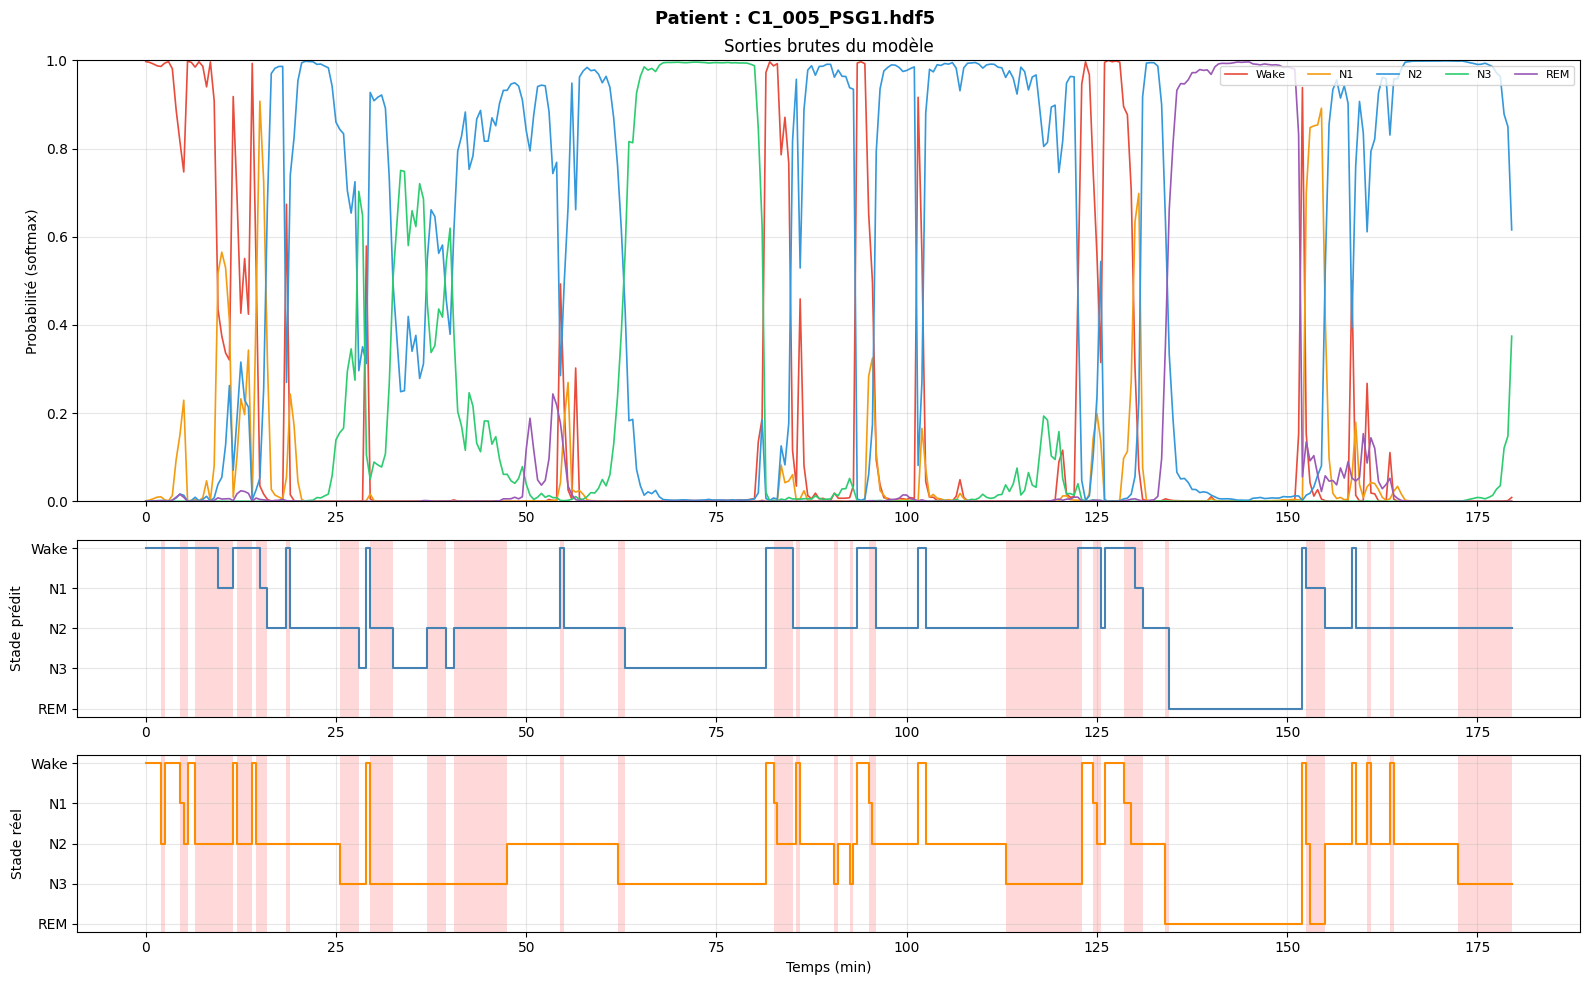


──────────────────────────────────────────────────
Patient : C1_005_PSG1.hdf5
  Epochs valides : 360
  Accuracy       : 68.3%
  Distribution labels  : {'Wake': 33, 'N1': 6, 'N2': 162, 'N3': 119, 'REM': 40}
  Distribution prédits : {'Wake': 59, 'N1': 13, 'N2': 203, 'N3': 50, 'REM': 35}


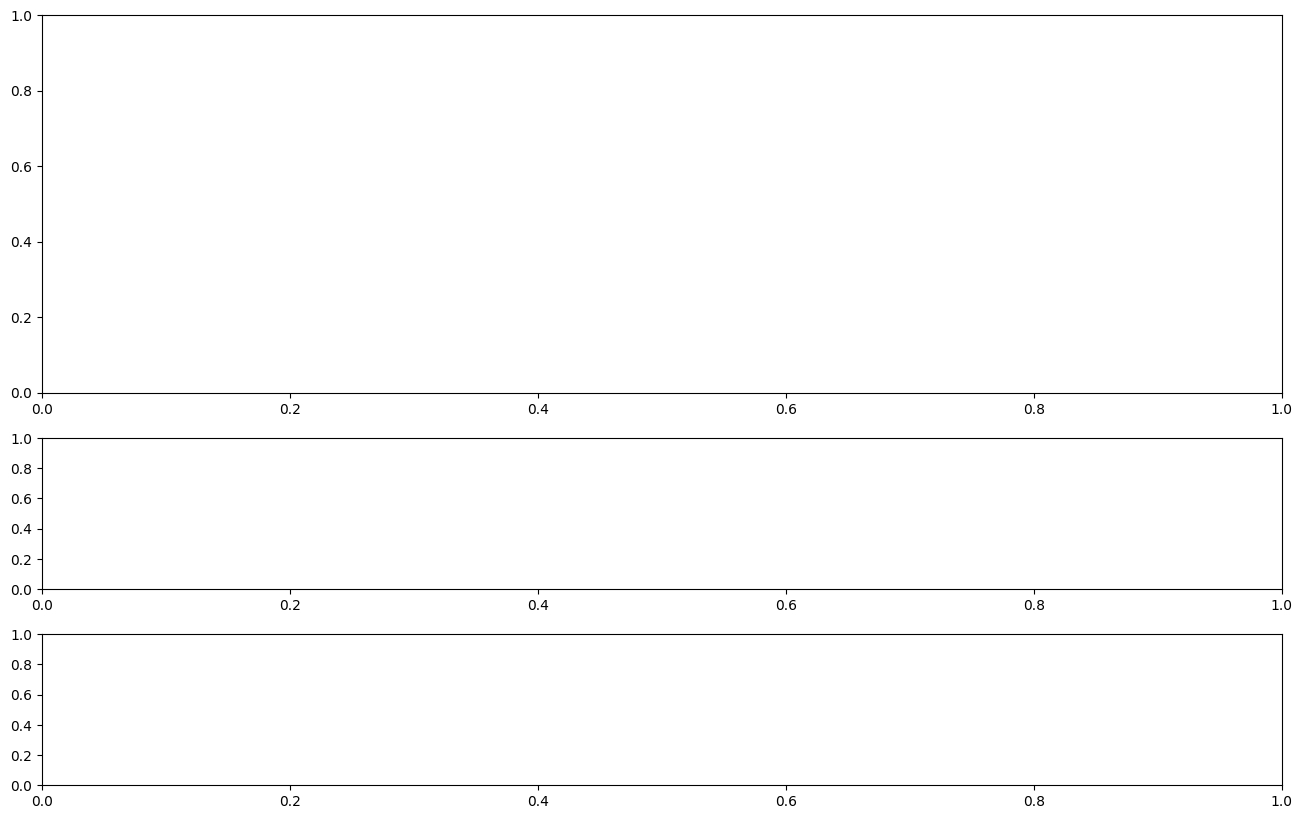

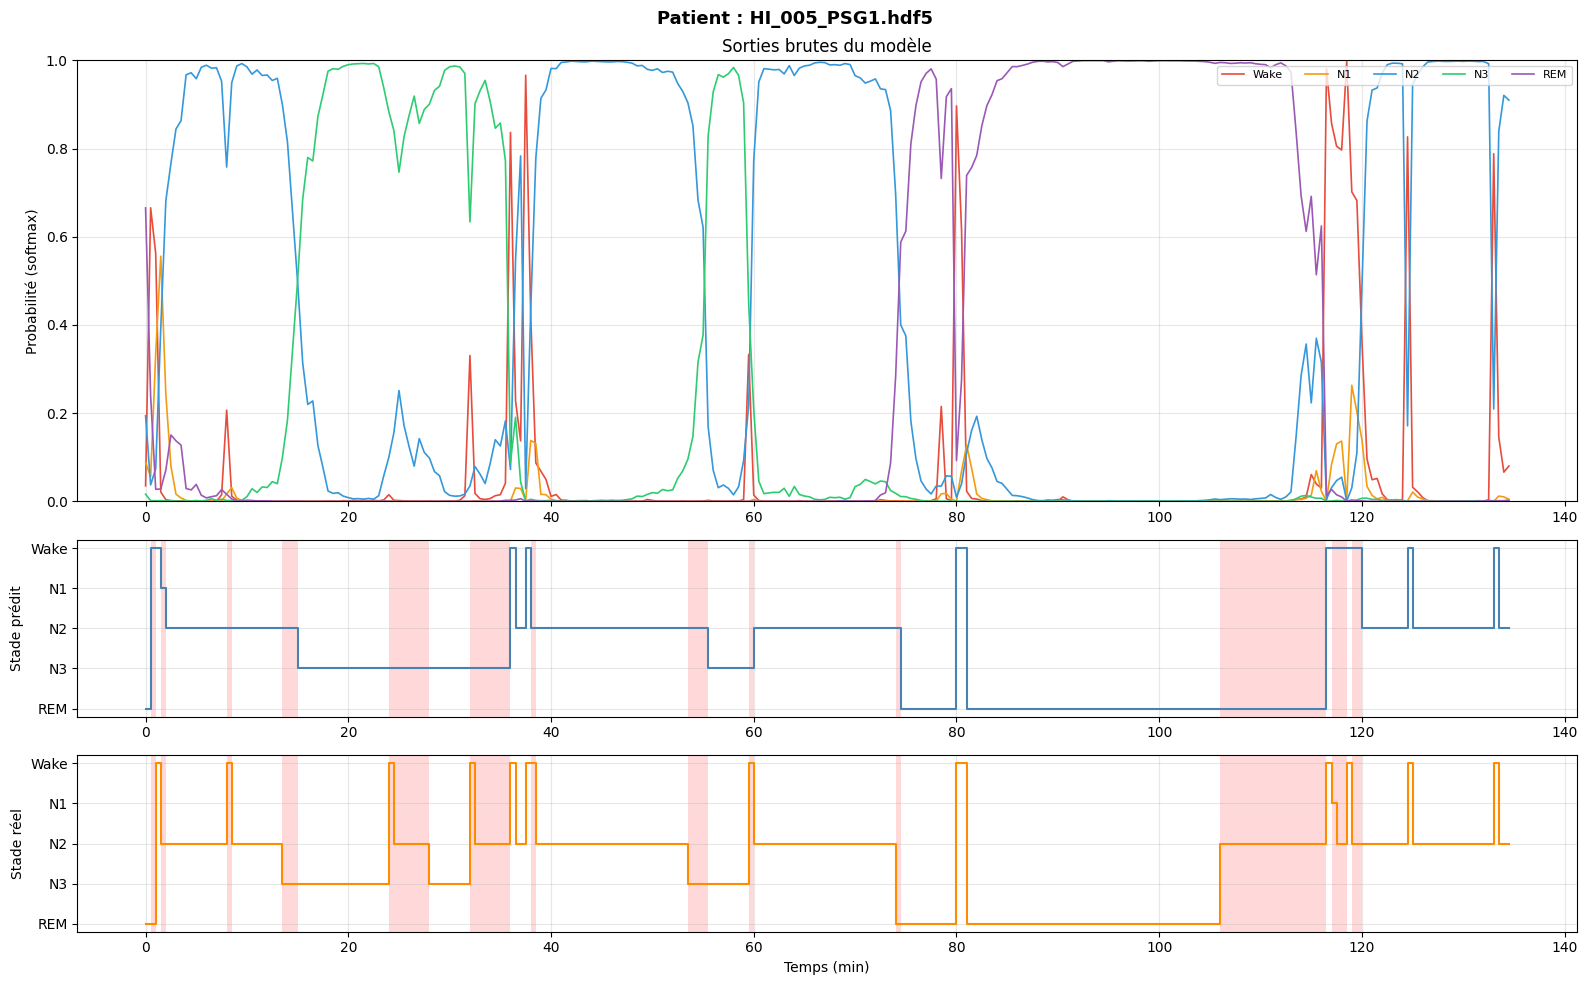


──────────────────────────────────────────────────
Patient : HI_005_PSG1.hdf5
  Epochs valides : 270
  Accuracy       : 79.6%
  Distribution labels  : {'Wake': 14, 'N1': 1, 'N2': 150, 'N3': 41, 'REM': 64}
  Distribution prédits : {'Wake': 15, 'N1': 1, 'N2': 120, 'N3': 51, 'REM': 83}


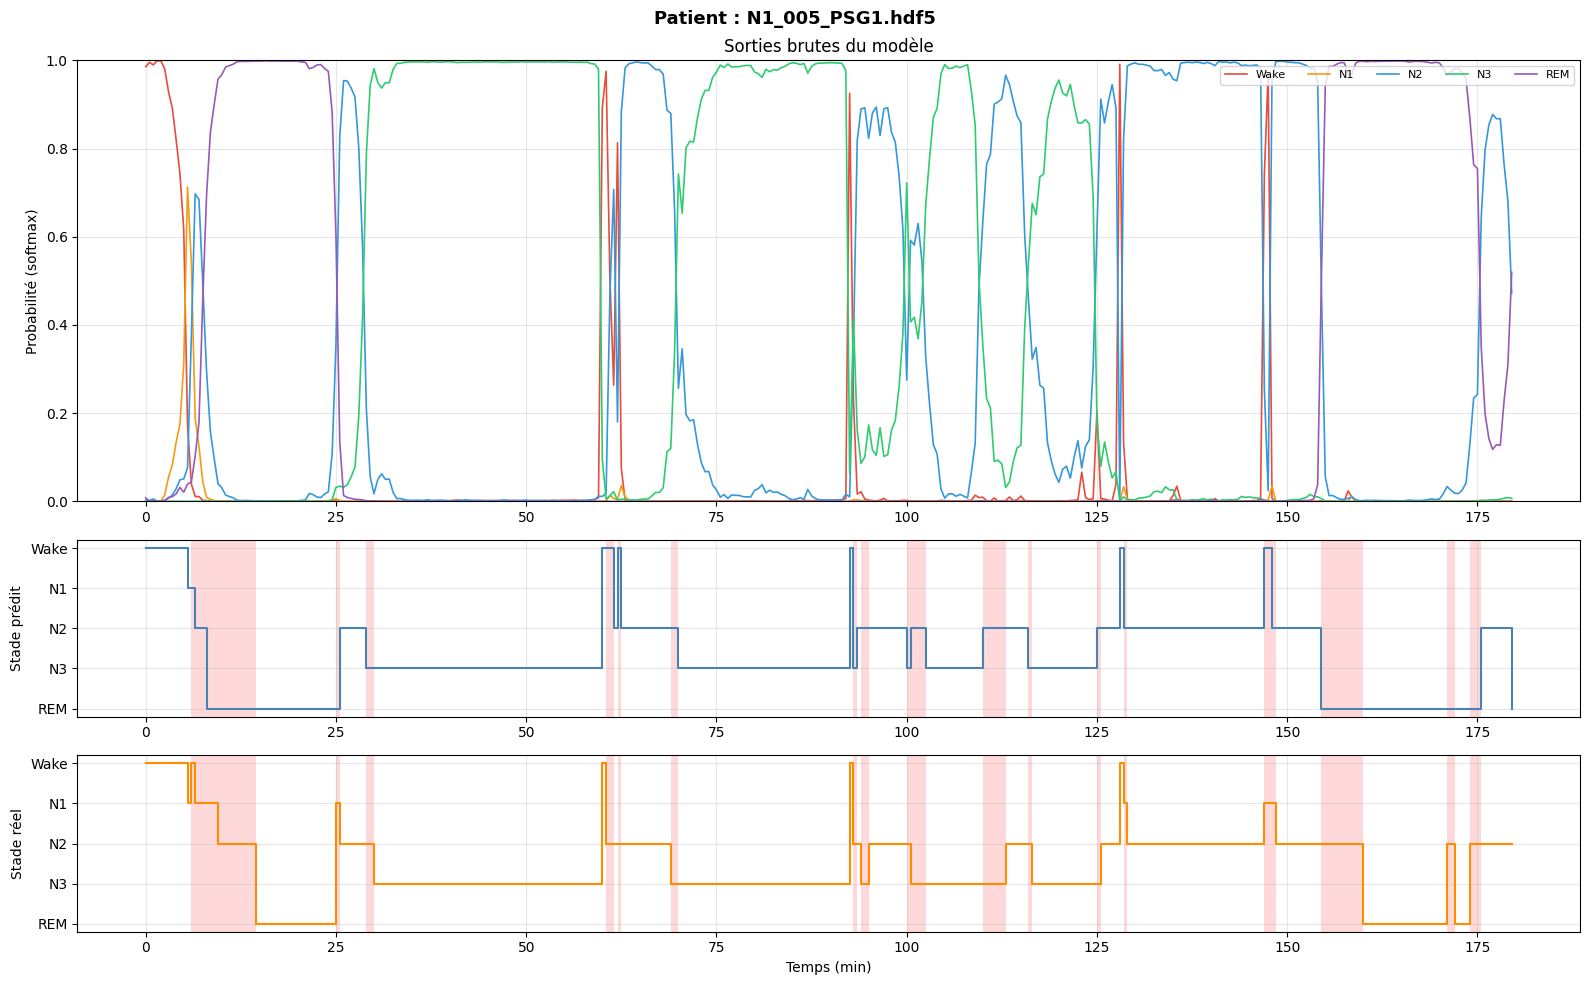


──────────────────────────────────────────────────
Patient : N1_005_PSG1.hdf5
  Epochs valides : 360
  Accuracy       : 82.8%
  Distribution labels  : {'Wake': 15, 'N1': 12, 'N2': 134, 'N3': 152, 'REM': 47}
  Distribution prédits : {'Wake': 19, 'N1': 2, 'N2': 119, 'N3': 142, 'REM': 78}


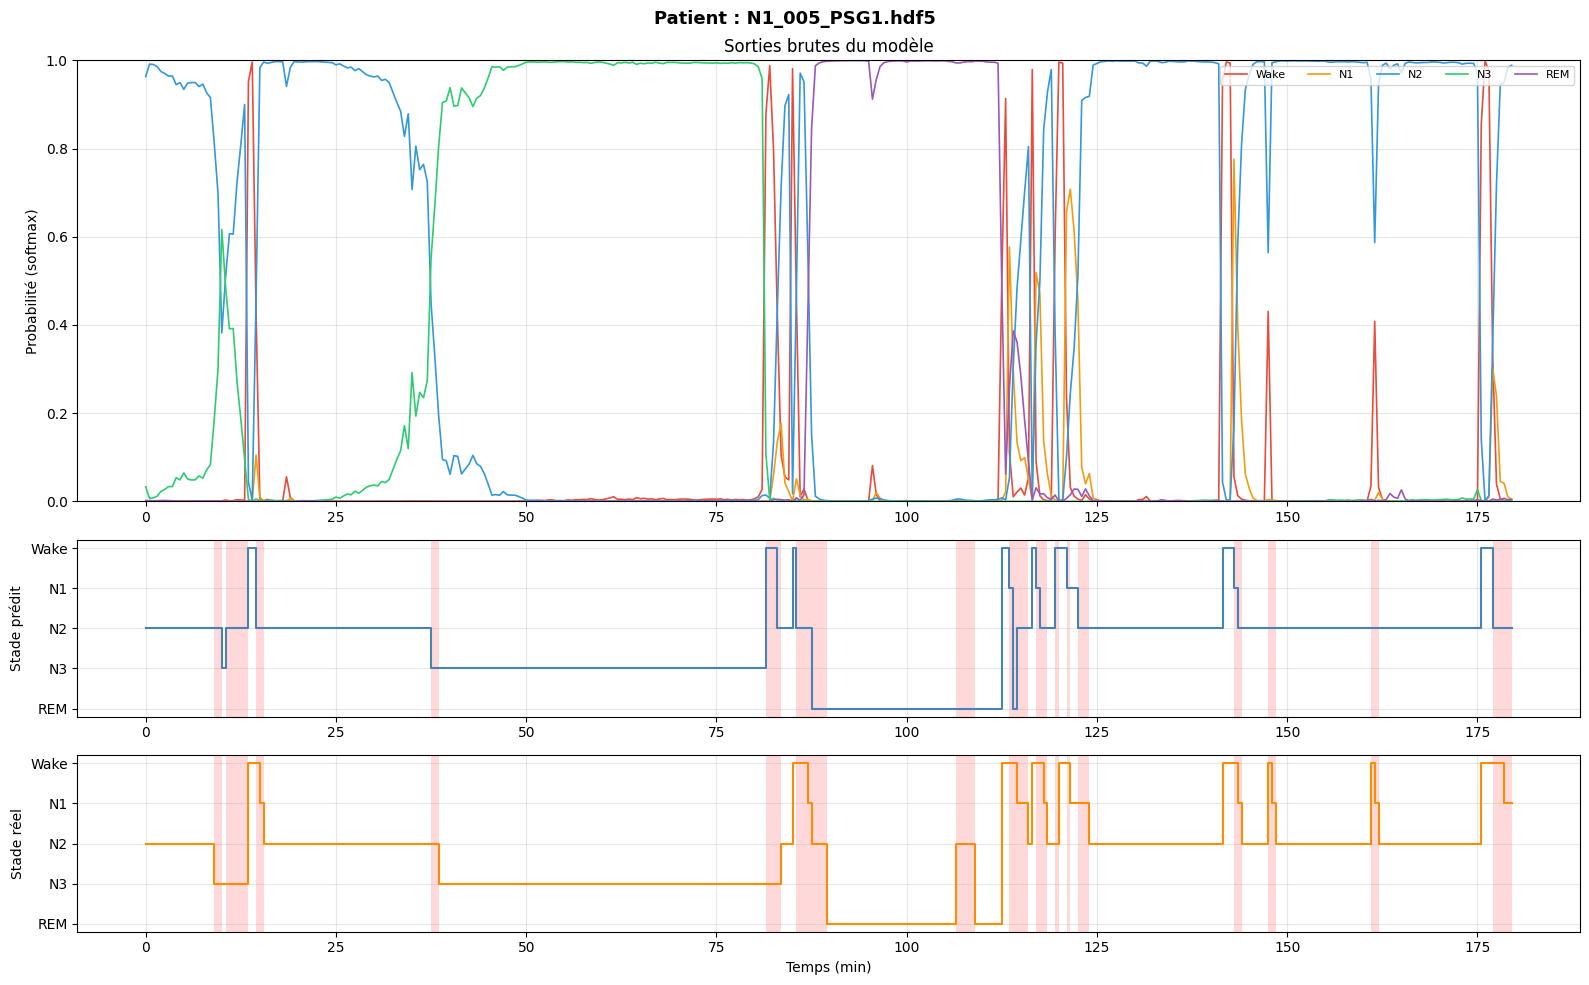


──────────────────────────────────────────────────
Patient : N1_005_PSG1.hdf5
  Epochs valides : 360
  Accuracy       : 85.0%
  Distribution labels  : {'Wake': 29, 'N1': 17, 'N2': 174, 'N3': 99, 'REM': 41}
  Distribution prédits : {'Wake': 18, 'N1': 6, 'N2': 196, 'N3': 89, 'REM': 51}


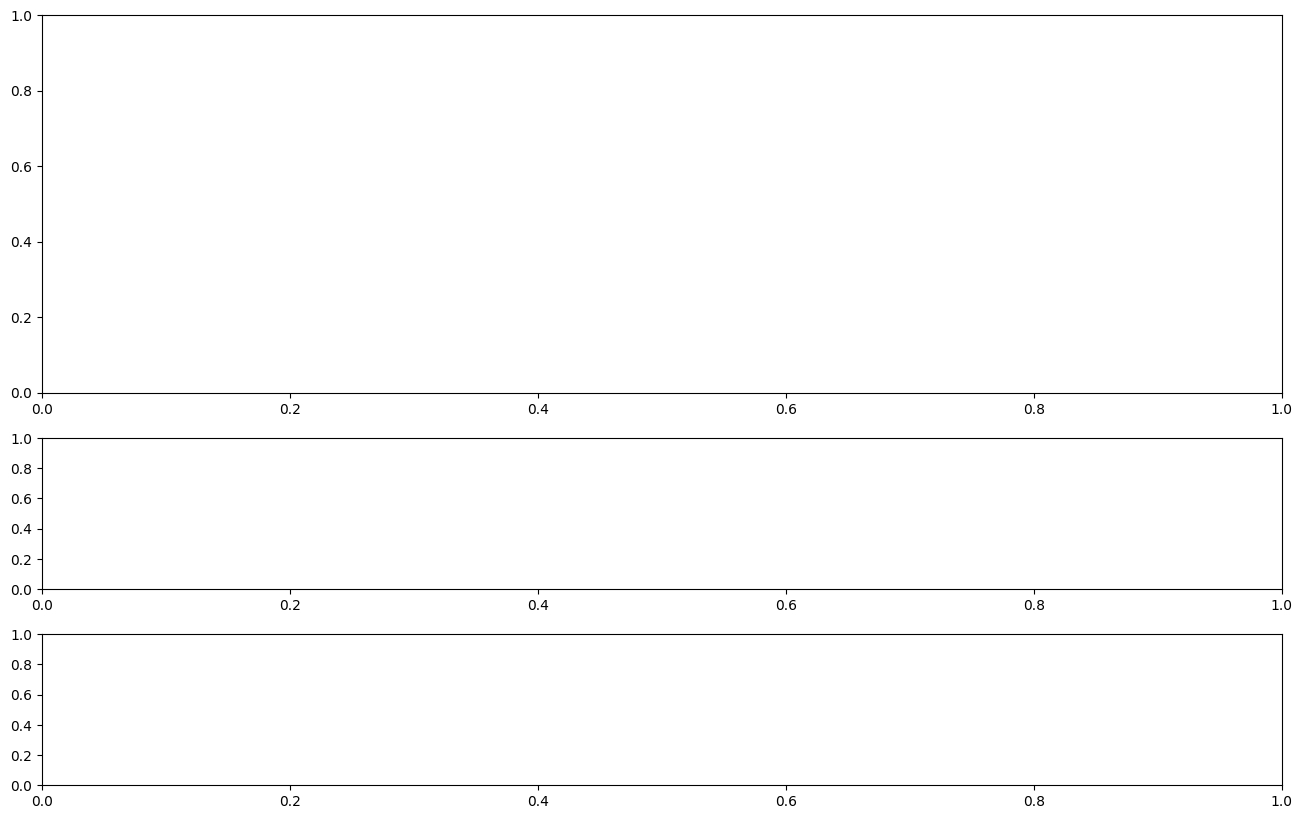

In [34]:

def inspect_model_output(model, dataloader, device, n_samples=6):
    """
    Affiche pour n_samples patients :
      - Les probabilités brutes (softmax) par classe au fil du temps
      - La comparaison prédiction vs label epoch par epoch
    """
    model.eval()
    samples_shown = 0
    test = [0, 0, 0]
    with torch.no_grad():
        for x_batch, y_batch, mask_batch, paths in dataloader:
            x_batch   = x_batch.to(device)
            y_batch   = y_batch.to(device)
            mask_batch = mask_batch.to(device)

            outputs = model(x_batch, mask_batch)

            # Unpack output (même logique que ton validate)
            if isinstance(outputs, tuple):
                logits, *_, mask_temporal = outputs
            else:
                logits = outputs
                mask_temporal = mask_batch[:, 0, :]
            B, T, C = logits.shape
            assert T % 6 == 0, f"T={T} n'est pas multiple de 6"

            logits = logits.view(B, T // 6, 6, C).mean(dim=2)   # [B, T30, C]

            if mask_temporal.dim() == 2:
                mask_temporal = mask_temporal[:, :T].contiguous()
                mask_temporal = mask_temporal.view(B, T // 6, 6)
                mask_temporal = mask_temporal.max(dim=2).values   # [B, T3
                    
            probs = torch.softmax(logits, dim=-1)  # (B, T, n_classes)
            preds = torch.argmax(logits, dim=-1)   # (B, T)
            for i in range(x_batch.shape[0]):
                if samples_shown >= n_samples:
                    return

                mask_i   = mask_temporal[i].cpu().numpy()        # (T,)
                valid     = mask_i == 0                          # epochs valides

                probs_i  = probs[i].cpu().numpy()[valid]         # (T_valid, n_classes)
                preds_i  = preds[i].cpu().numpy()[valid]         # (T_valid,)
                labels_i = y_batch[i].cpu().numpy()[valid]       # (T_valid,)
                n_epochs  = len(labels_i)
                time_axis = np.arange(n_epochs) * 30 / 60        # en minutes

                fig, axes = plt.subplots(3, 1, figsize=(16, 10),
                                         gridspec_kw={'height_ratios': [2.5, 1, 1]})
                patient_name = os.path.basename(paths[i])
                if patient_name.startswith("C1"):
                    if test[0] == 2:
                        break
                    test[0] += 1
                if patient_name.startswith("N1"):
                    if test[1] == 2:
                        break
                    test[1] += 1
                if patient_name.startswith("HI"):
                    if test[2] == 2:
                        break
                    test[2] += 1
                fig.suptitle(f"Patient : {patient_name}", fontsize=13, fontweight='bold')

                # ── 1. Probabilités brutes ──────────────────────────────────────
                ax = axes[0]
                for cls in range(probs_i.shape[1]):
                    ax.plot(time_axis, probs_i[:, cls],
                            label=STAGE_NAMES.get(cls, str(cls)),
                            color=COLORS.get(cls, "gray"), linewidth=1.2)
                ax.set_ylabel("Probabilité (softmax)")
                ax.set_title("Sorties brutes du modèle")
                ax.legend(loc="upper right", ncol=5, fontsize=8)
                ax.set_ylim(0, 1)
                ax.grid(alpha=0.3)

                # ── 2. Hypnogramme prédit ───────────────────────────────────────
                ax = axes[1]
                ax.step(time_axis, preds_i, where='post',
                        color='steelblue', linewidth=1.5, label="Prédit")
                ax.set_yticks(list(STAGE_NAMES.keys()))
                ax.set_yticklabels([STAGE_NAMES[k] for k in STAGE_NAMES])
                ax.set_ylabel("Stade prédit")
                ax.invert_yaxis()
                ax.grid(alpha=0.3)

                # ── 3. Hypnogramme label (vérité terrain) ──────────────────────
                ax = axes[2]
                ax.step(time_axis, labels_i, where='post',
                        color='darkorange', linewidth=1.5, label="Label")
                ax.set_yticks(list(STAGE_NAMES.keys()))
                ax.set_yticklabels([STAGE_NAMES[k] for k in STAGE_NAMES])
                ax.set_ylabel("Stade réel")
                ax.set_xlabel("Temps (min)")
                ax.invert_yaxis()
                ax.grid(alpha=0.3)

                # ── Colorier les erreurs en rouge ───────────────────────────────
                for t in range(n_epochs - 1):
                    if preds_i[t] != labels_i[t]:
                        for a in axes[1:]:
                            a.axvspan(time_axis[t], time_axis[t+1],
                                      alpha=0.15, color='red', linewidth=0)

                plt.tight_layout()
                plt.show()

                # ── Stats rapides en console ────────────────────────────────────
                acc = (preds_i == labels_i).mean()
                print(f"\n{'─'*50}")
                print(f"Patient : {patient_name}")
                print(f"  Epochs valides : {n_epochs}")
                print(f"  Accuracy       : {acc:.1%}")
                print(f"  Distribution labels  : { {STAGE_NAMES[k]: int((labels_i==k).sum()) for k in STAGE_NAMES if (labels_i==k).any()} }")
                print(f"  Distribution prédits : { {STAGE_NAMES[k]: int((preds_i==k).sum()) for k in STAGE_NAMES if (preds_i==k).any()} }")

                samples_shown += 1



inspect_model_output(sleep_staging_model2, val_loader, device, n_samples=6)

In [35]:
train_hdf5 = []
train_labels = []
val_hdf5 = []
val_labels = []
val = [0,0,0]
for i,j in file_pairs:
    hdf5_basename = os.path.basename(i).replace('.hdf5', '')
    if hdf5_basename.startswith("C1"):
        if val[0] <= 3:
            val[0] += 1
            train_hdf5.append(i)
            train_labels.append(j)
        else:
            val_hdf5.append(i)
            val_labels.append(j)
    elif hdf5_basename.startswith("N1"):
        if val[1] <= 3:
            val[1] += 1
            train_hdf5.append(i)
            train_labels.append(j)
        else:
            val_hdf5.append(i)
            val_labels.append(j)
    elif hdf5_basename.startswith("HI"):
        if val[2] <= 3:
            val[2] += 1
            train_hdf5.append(i)
            train_labels.append(j)
        else:
            val_hdf5.append(i)
            val_labels.append(j)


train_dataset = SleepEventClassificationDataset(
        config_ent, 
        CHANNEL_GROUPS_FOR_MODEL, 
        split="train", 
        hdf5_paths=train_hdf5, 
        label_files=train_labels
    )

train_loader = DataLoader(
        train_dataset,
        batch_size=config_ent['batch_size'],
        shuffle=True,
        num_workers=0,  
        collate_fn=sleep_event_finetune_full_collate_fn,
        pin_memory=True if torch.cuda.is_available() else False
    )

Indexing train data: 100%|██████████| 12/12 [00:00<00:00, 1478.86it/s]


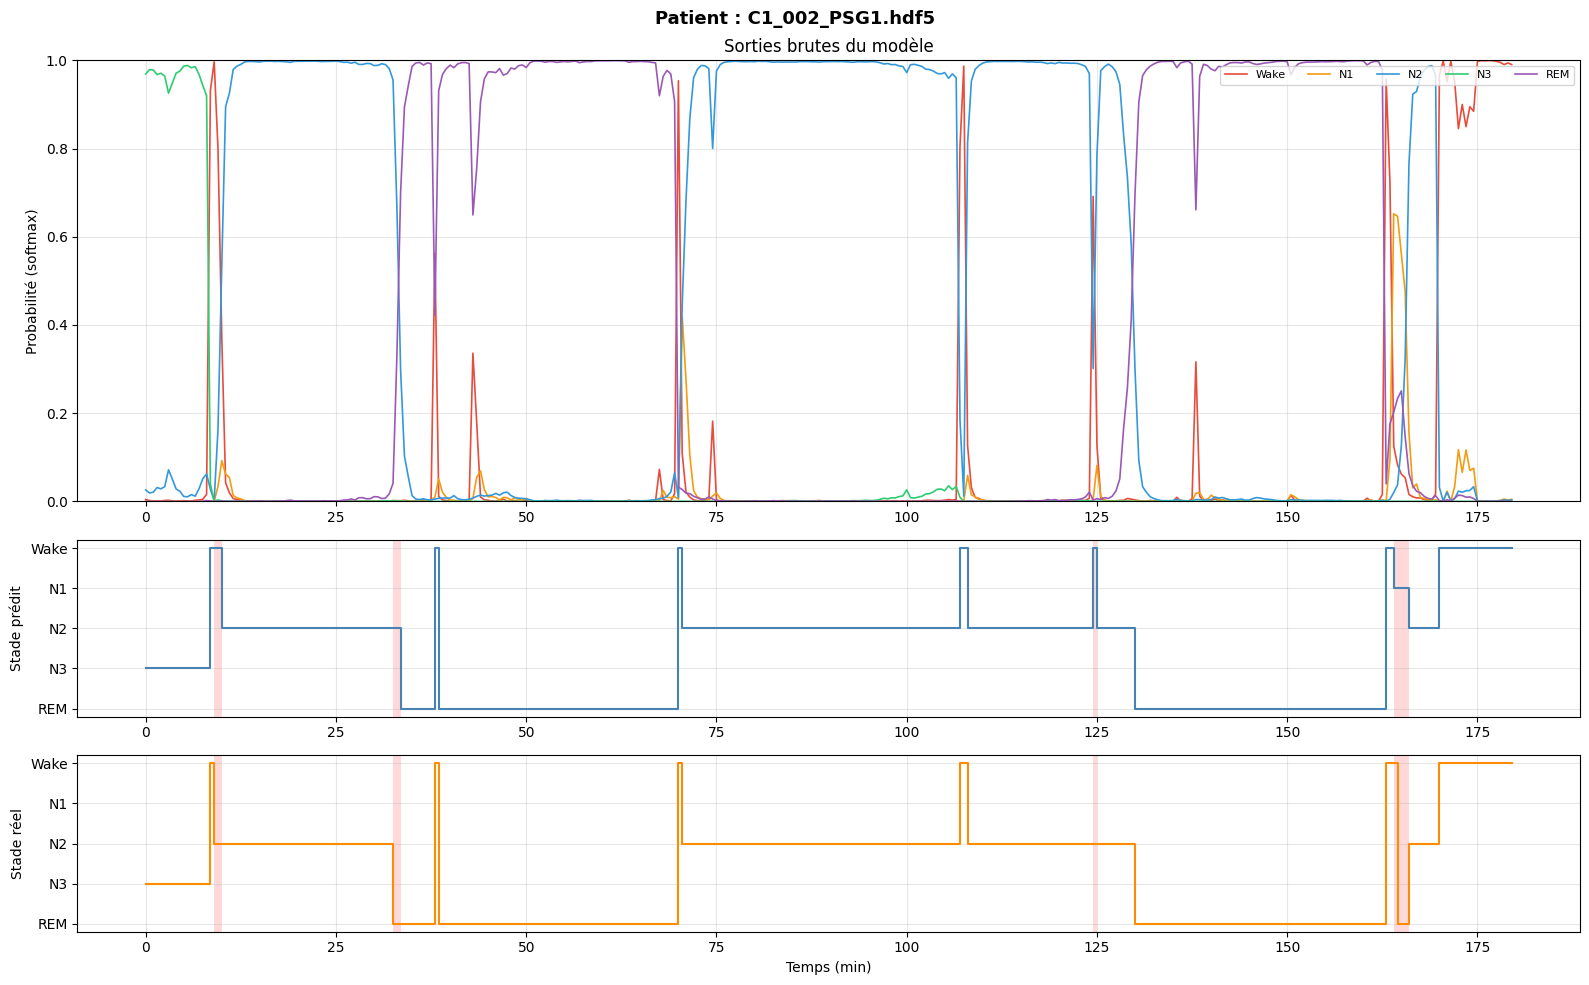


──────────────────────────────────────────────────
Patient : C1_002_PSG1.hdf5
  Epochs valides : 360
  Accuracy       : 97.5%
  Distribution labels  : {'Wake': 28, 'N2': 172, 'N3': 17, 'REM': 143}
  Distribution prédits : {'Wake': 30, 'N1': 4, 'N2': 171, 'N3': 17, 'REM': 138}


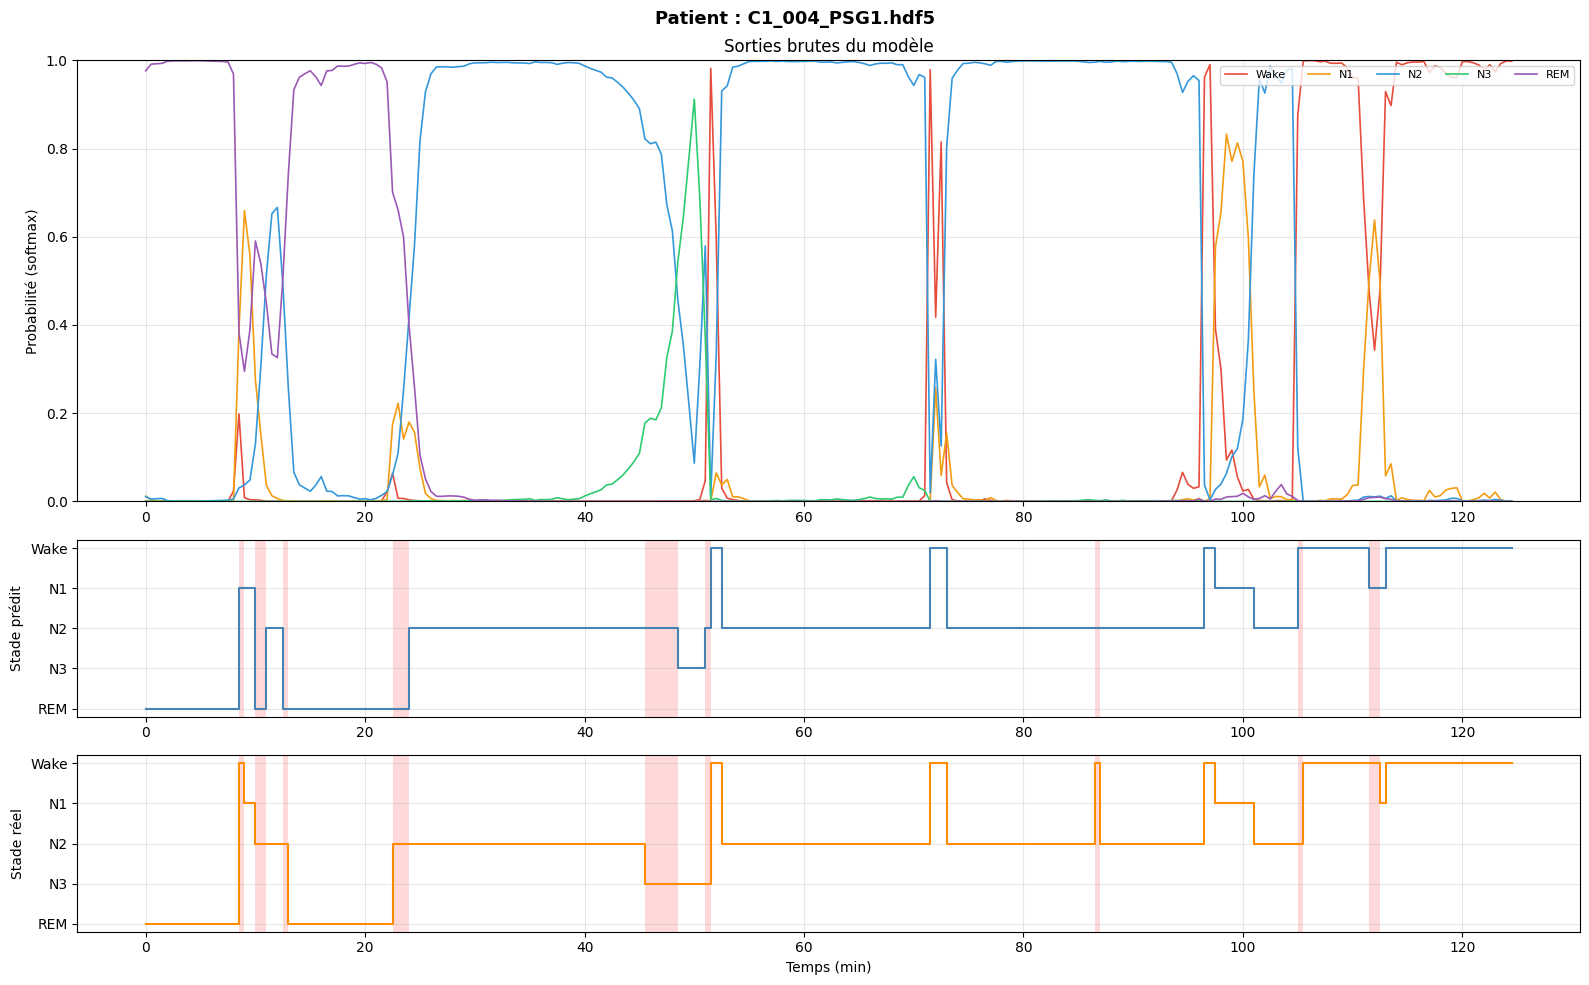


──────────────────────────────────────────────────
Patient : C1_004_PSG1.hdf5
  Epochs valides : 250
  Accuracy       : 92.8%
  Distribution labels  : {'Wake': 47, 'N1': 10, 'N2': 145, 'N3': 12, 'REM': 36}
  Distribution prédits : {'Wake': 44, 'N1': 13, 'N2': 146, 'N3': 5, 'REM': 42}


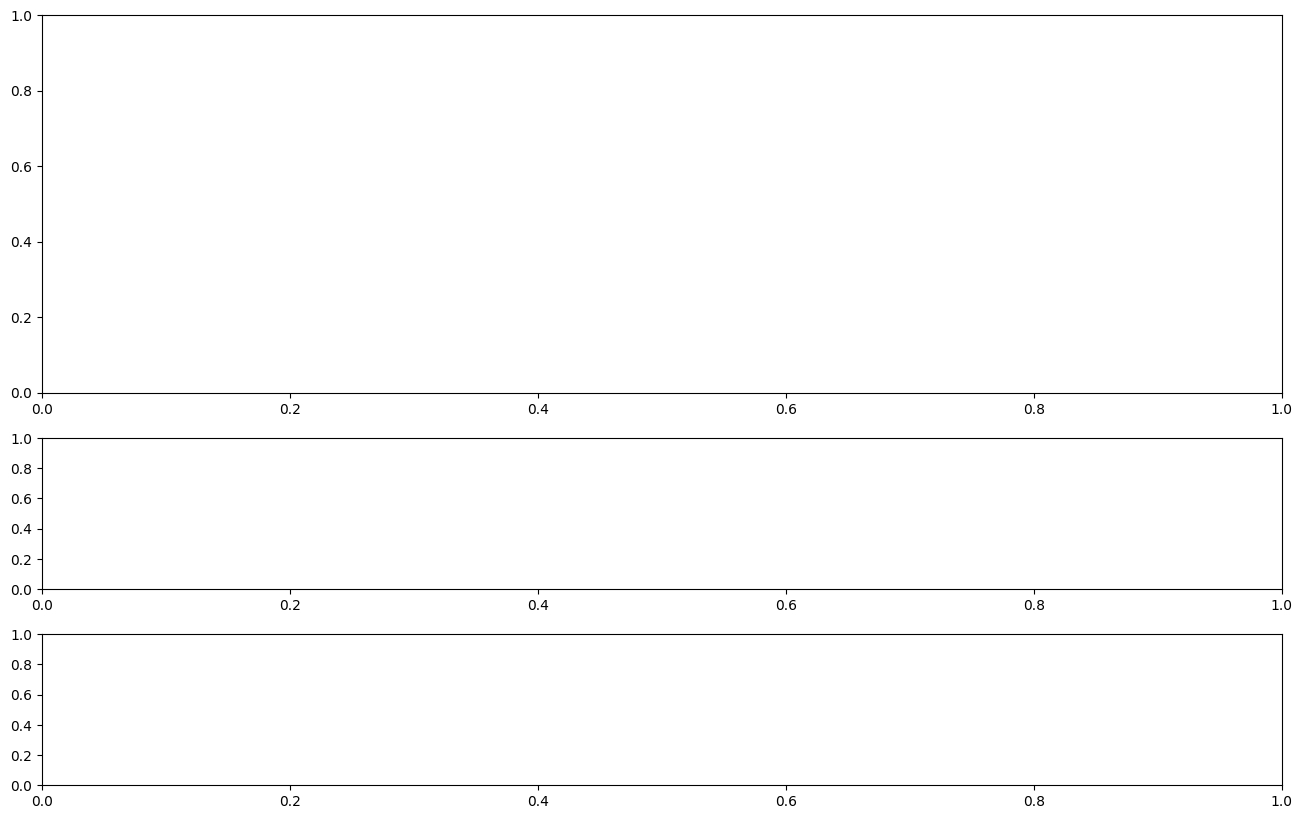

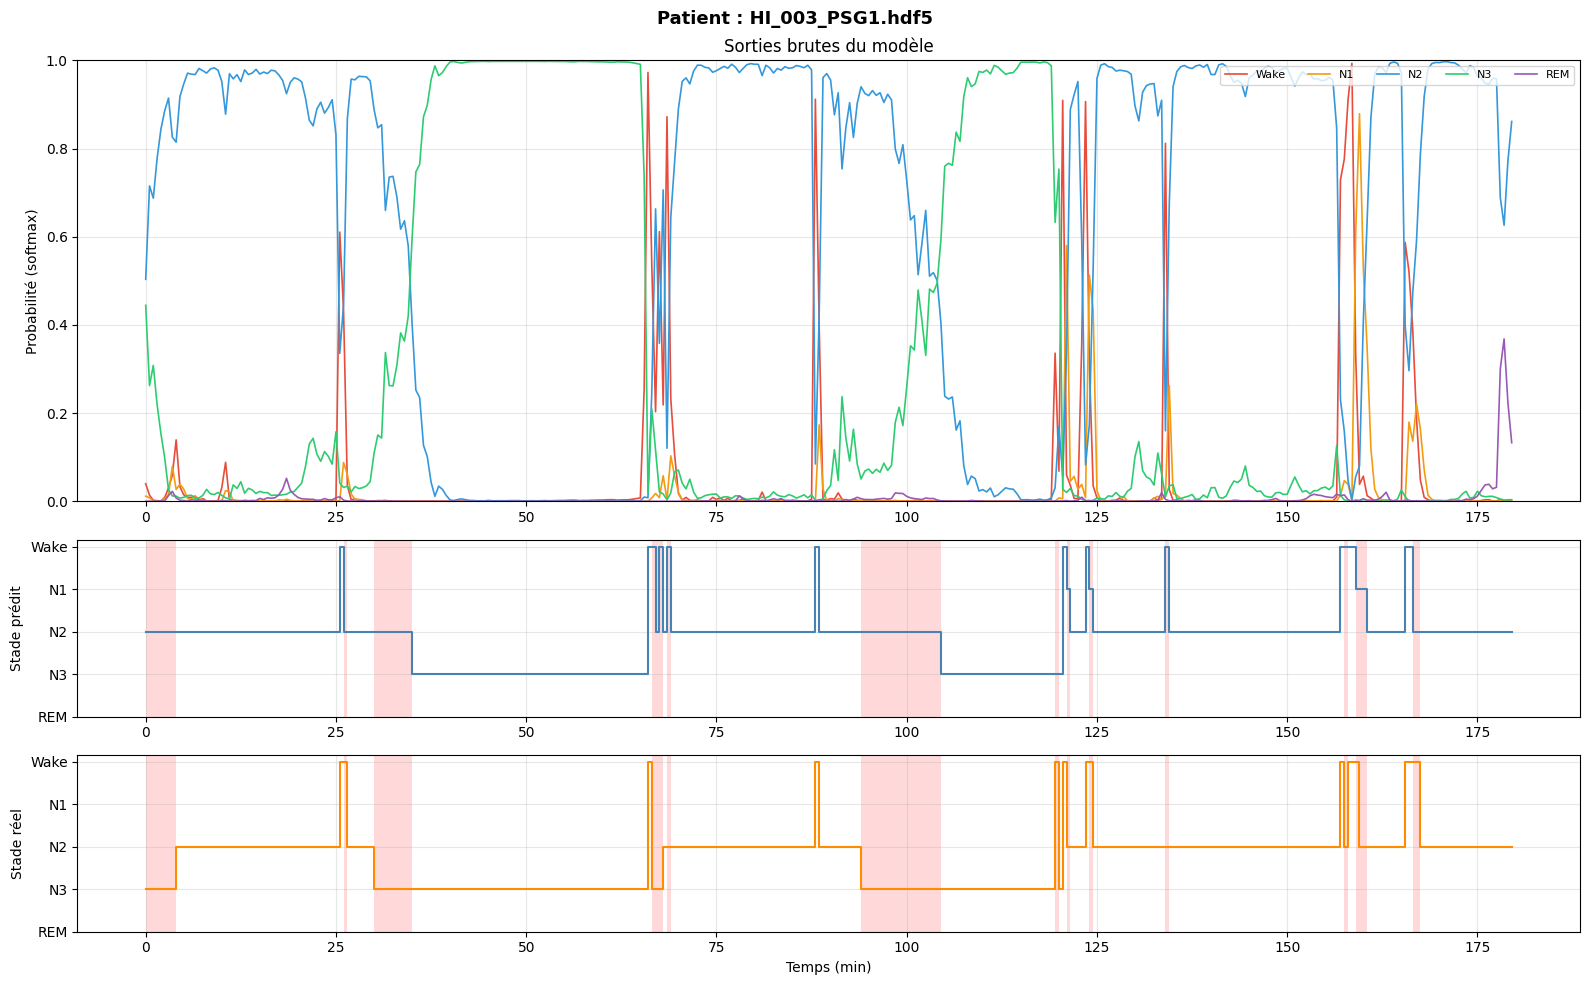


──────────────────────────────────────────────────
Patient : HI_003_PSG1.hdf5
  Epochs valides : 360
  Accuracy       : 85.0%
  Distribution labels  : {'Wake': 16, 'N2': 209, 'N3': 135}
  Distribution prédits : {'Wake': 15, 'N1': 5, 'N2': 246, 'N3': 94}


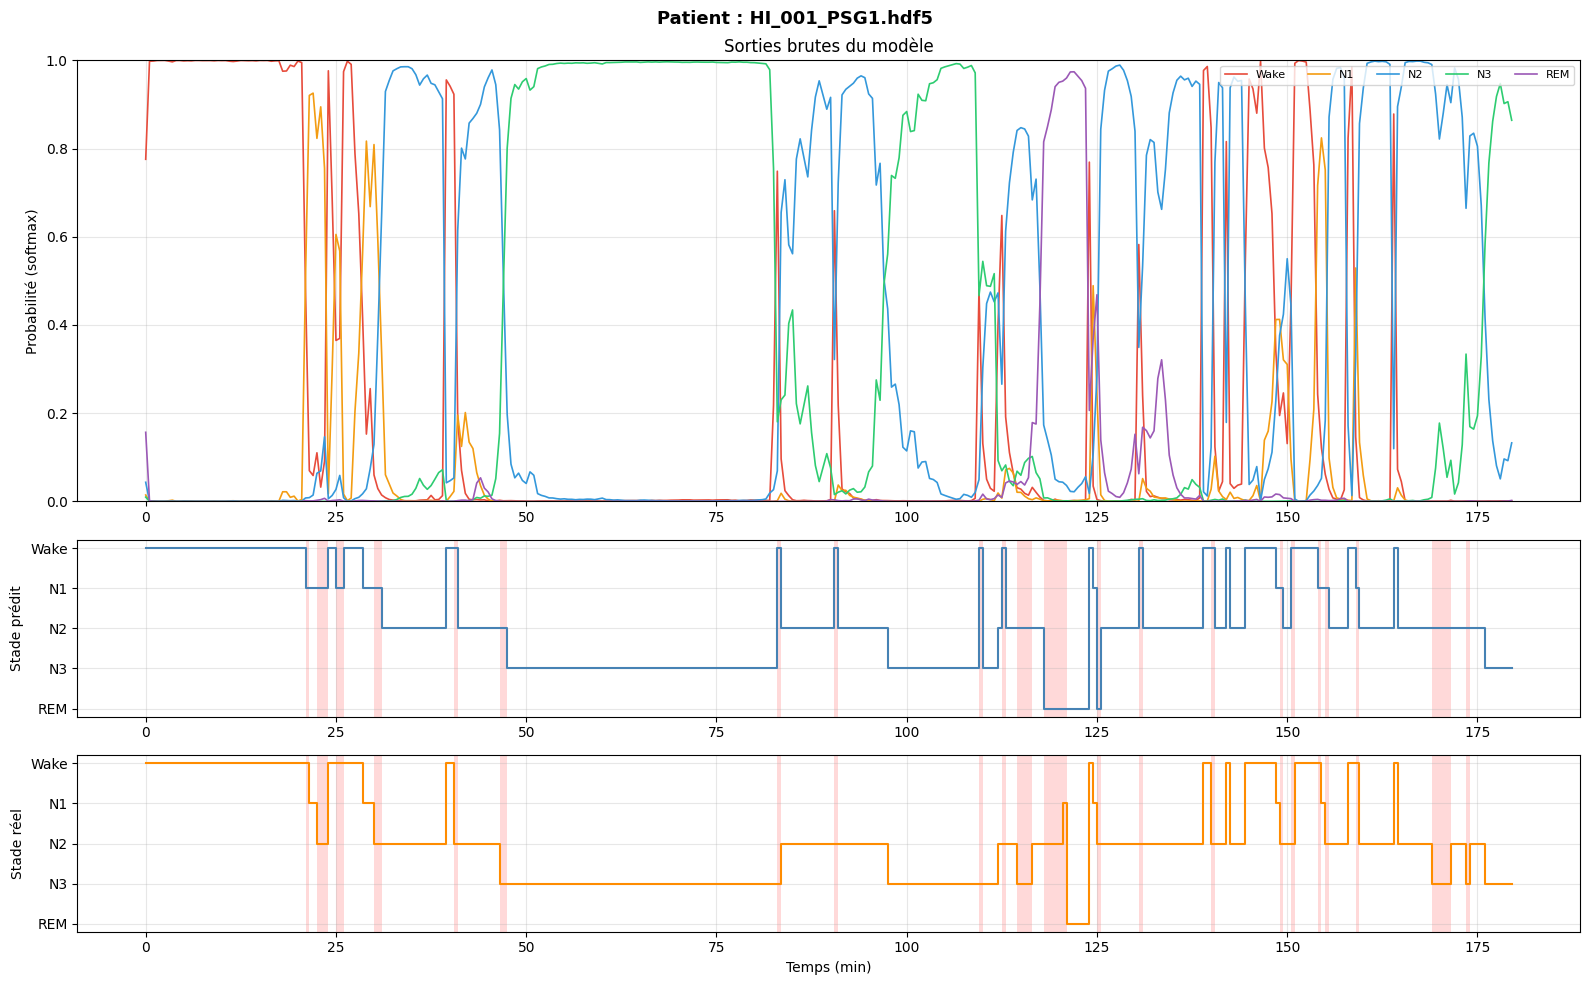


──────────────────────────────────────────────────
Patient : HI_001_PSG1.hdf5
  Epochs valides : 360
  Accuracy       : 89.2%
  Distribution labels  : {'Wake': 77, 'N1': 9, 'N2': 147, 'N3': 121, 'REM': 6}
  Distribution prédits : {'Wake': 80, 'N1': 20, 'N2': 140, 'N3': 107, 'REM': 13}


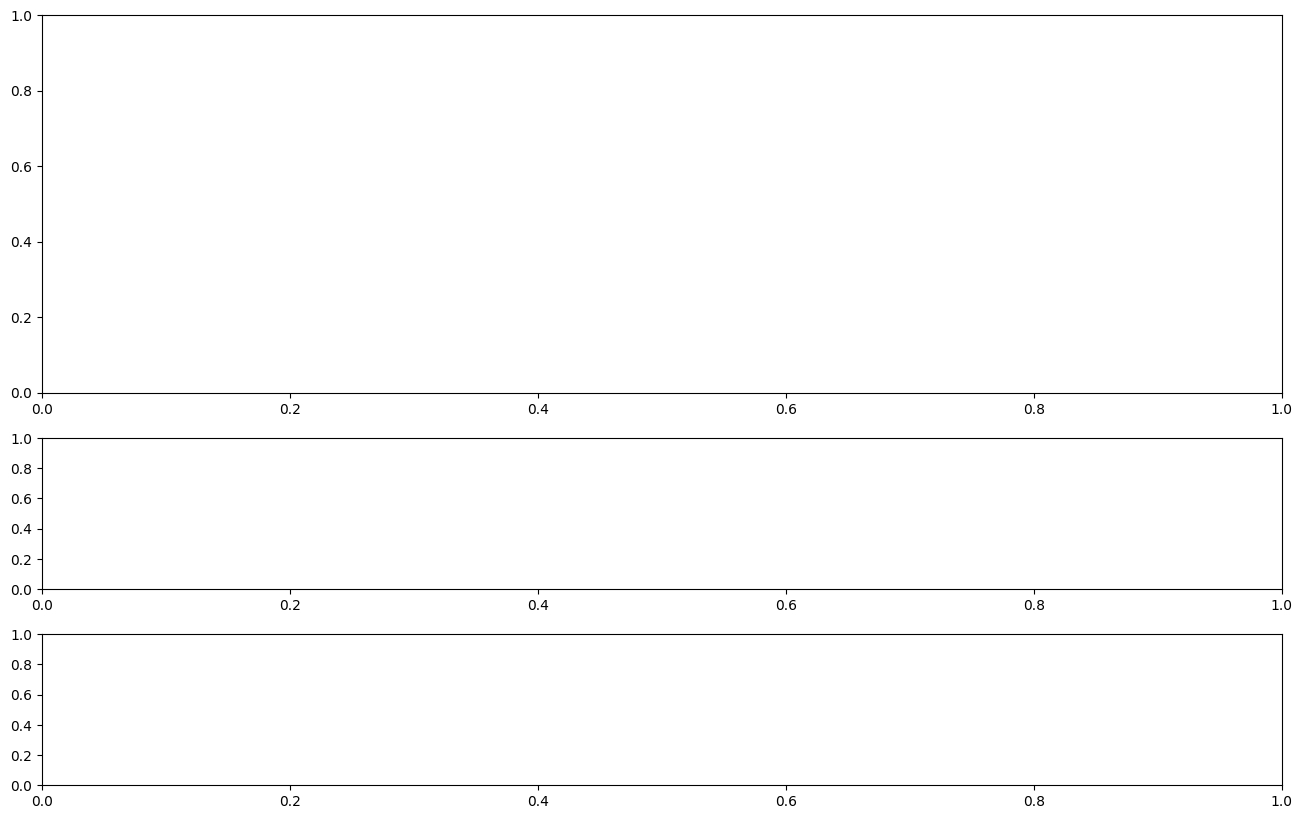

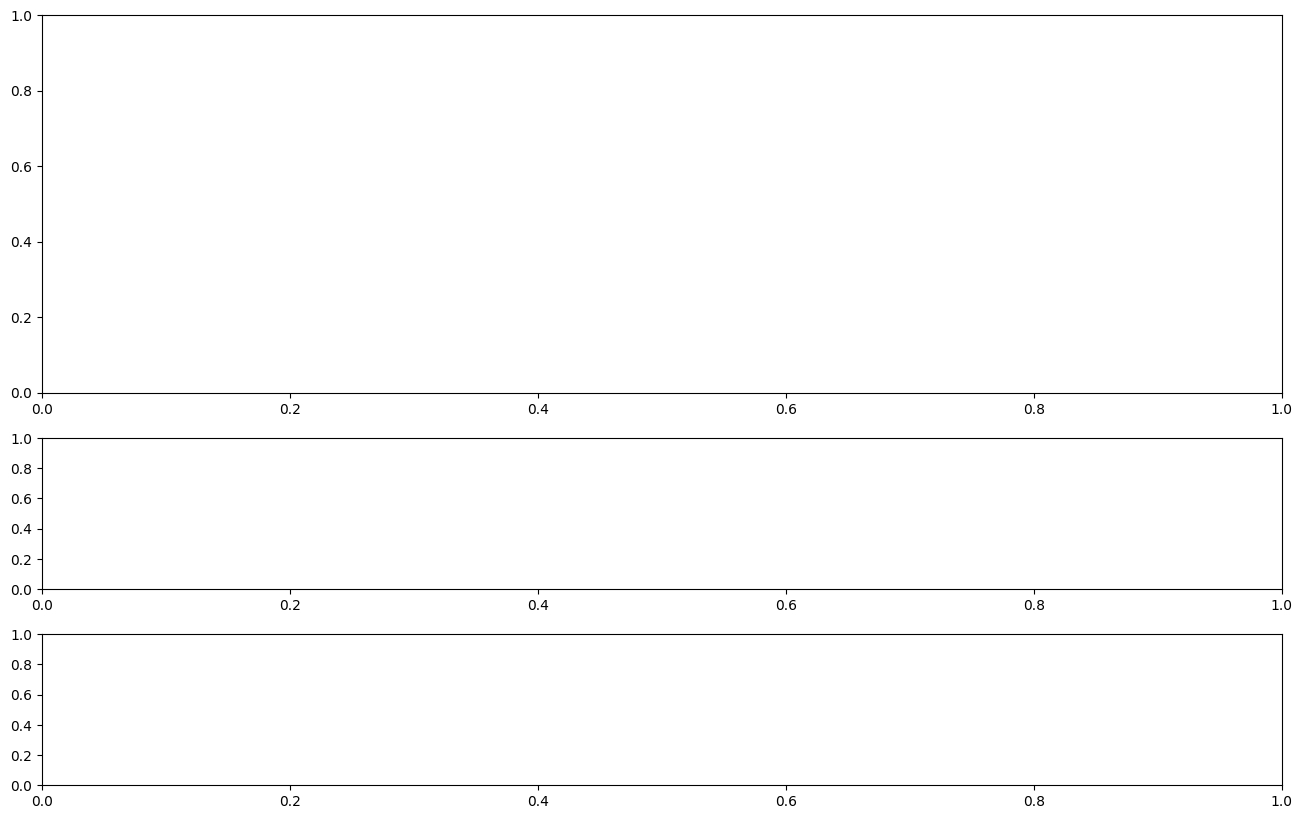

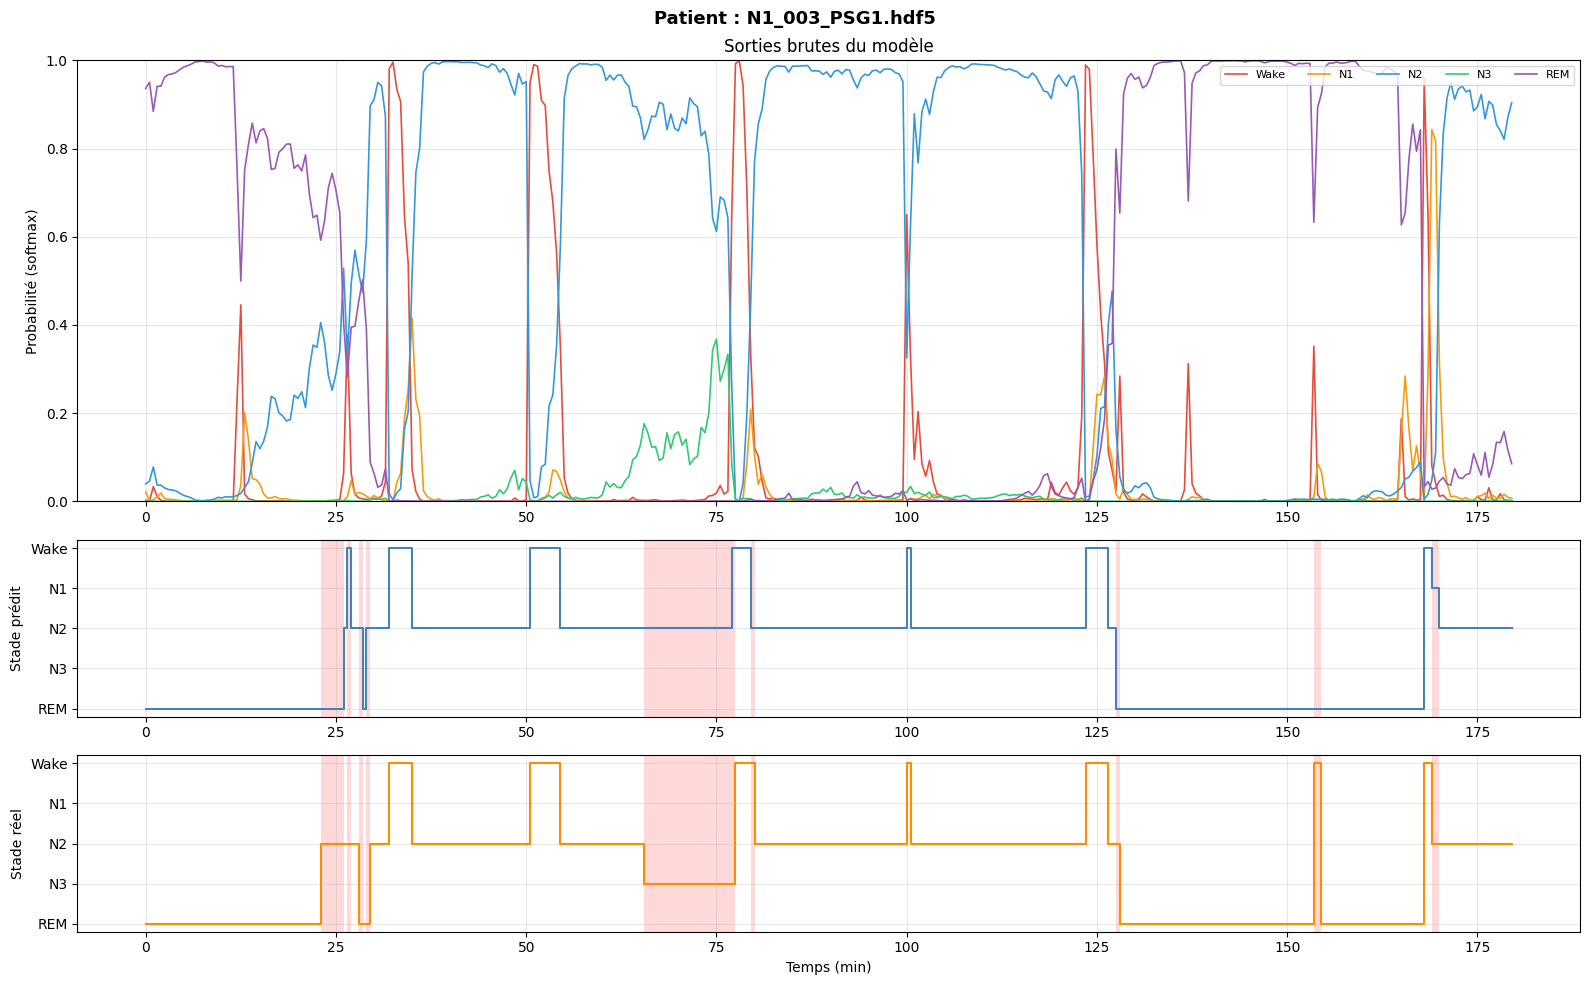


──────────────────────────────────────────────────
Patient : N1_003_PSG1.hdf5
  Epochs valides : 360
  Accuracy       : 89.2%
  Distribution labels  : {'Wake': 30, 'N2': 179, 'N3': 24, 'REM': 127}
  Distribution prédits : {'Wake': 29, 'N1': 2, 'N2': 195, 'REM': 134}


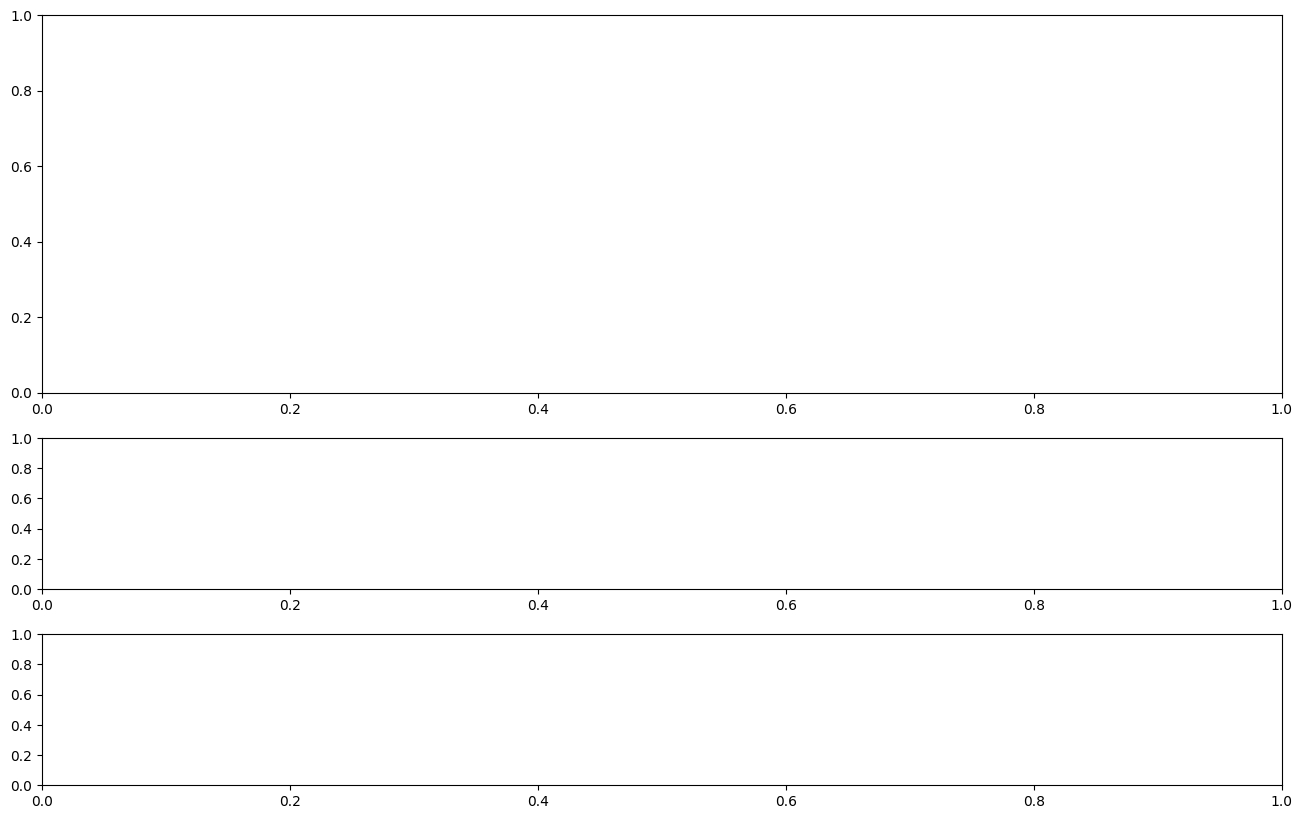

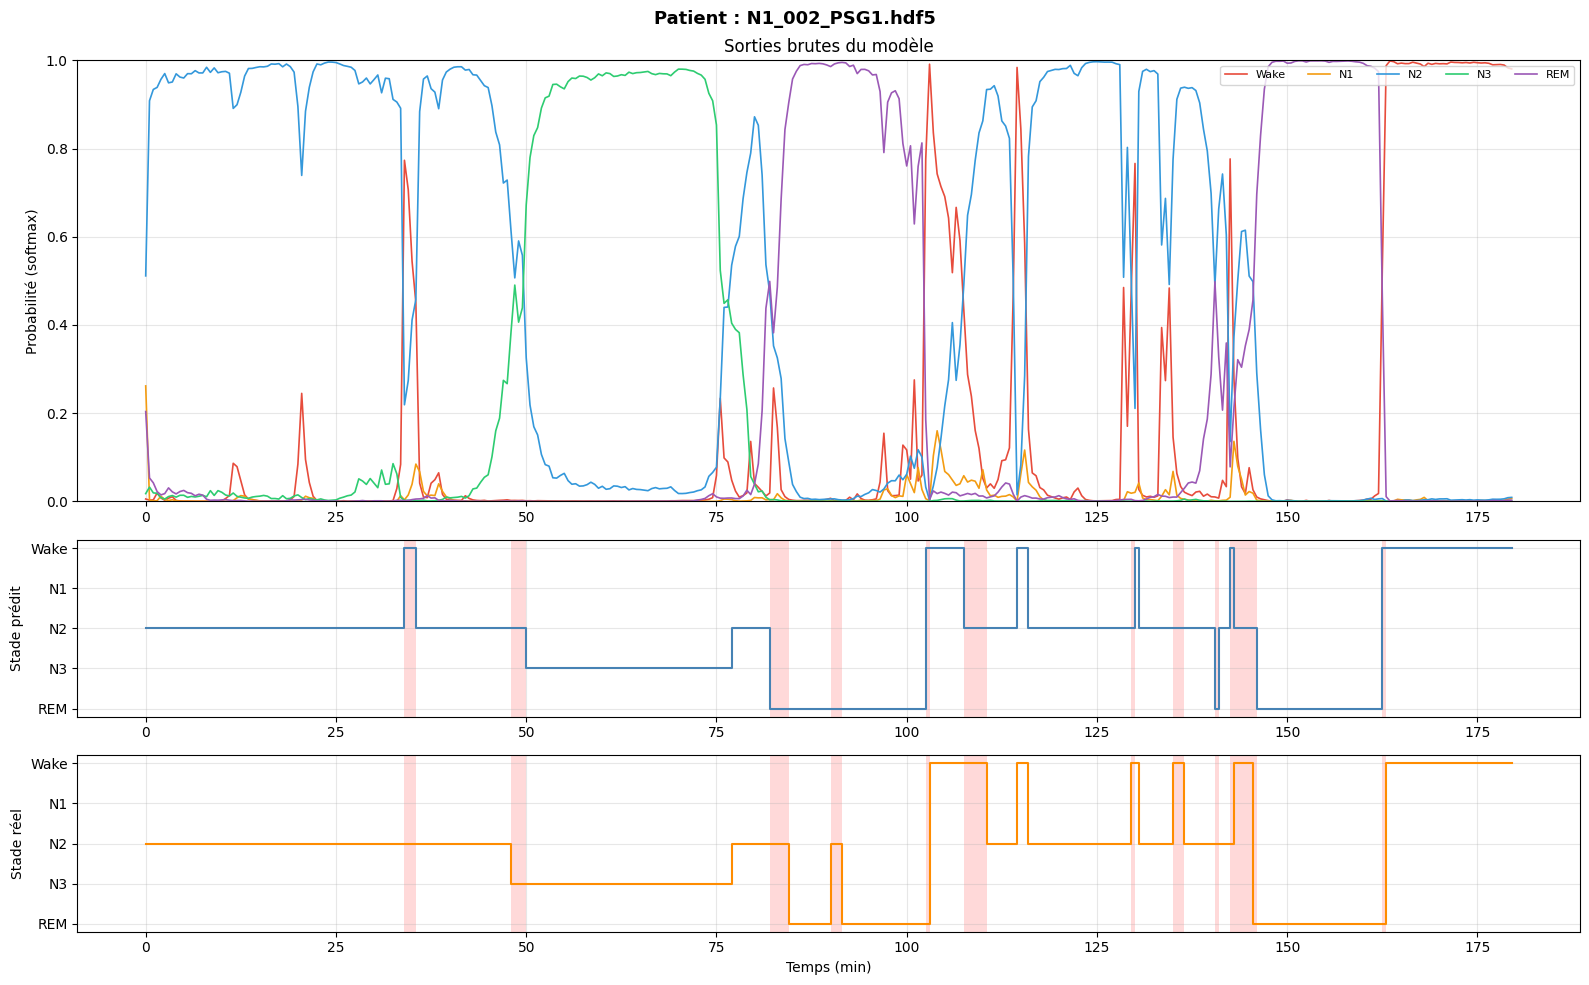


──────────────────────────────────────────────────
Patient : N1_002_PSG1.hdf5
  Epochs valides : 360
  Accuracy       : 90.3%
  Distribution labels  : {'Wake': 62, 'N2': 171, 'N3': 58, 'REM': 69}
  Distribution prédits : {'Wake': 53, 'N2': 178, 'N3': 54, 'REM': 75}


In [36]:

inspect_model_output(sleep_staging_model2, train_loader, device, n_samples=6)